<a href="https://colab.research.google.com/github/ben-g26/Rusting_Rivers/blob/main/Rusting_Rivers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from codecarbon import EmissionsTracker

tracker = EmissionsTracker()
tracker.start()

# notebook work here



[codecarbon WARNING @ 18:24:53] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:24:53] [setup] RAM Tracking...
[codecarbon INFO @ 18:24:53] [setup] CPU Tracking...
[codecarbon WARNING @ 18:24:53] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 18:24:53] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 18:24:53] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 18:24:53] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 18:24:53] [setup] GPU Tracking...
[codecarbon INFO @ 18:24:53] No GPU found.
[codecarbon INFO @ 18:24:53] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation mo

The principal component analysis (PCA) space was constructed using only the rust-affected rivers, while retaining observations from both 2017 and 2020. Control rivers were subsequently projected into this fixed PCA space without contributing to the estimation of the PCA basis vectors. This approach was adopted to ensure that the dominant axes of variability reflected the structure and temporal evolution of the rusting systems themselves, rather than broader environmental differences introduced by unrelated control rivers. Including controls directly in PCA estimation risks allocating major components to inter-river variability associated with geomorphology, vegetation, sediment composition, or illumination conditions, potentially obscuring subtler temporal transitions associated with river rusting. By fitting PCA exclusively on rust-affected systems, the resulting embedding space is more sensitive to the dominant modes of variability within the phenomenon of interest, while still allowing controls to serve as external comparisons through out-of-sample projection. A limitation of this approach is that the resulting PCA space becomes partially conditioned on the selected rusting rivers and may therefore underrepresent environmental variability outside the affected systems. Additionally, because PCA is applied to the original embeddings rather than temporal difference vectors, the resulting components still capture a mixture of spatial and temporal variability. Nevertheless, this framework provides a balance between interpretability, comparability, and sensitivity to rust-associated transitions.


### 2. Data Preparation and Pixel-Level Embedding Extraction

For each river:
- embedding pixels were sampled from AlphaEarth 64-dimensional annual embeddings
- only pixels valid in both 2017 and 2020 were retained
- pixel sets were balanced across rivers to ensure equal contribution during analysis

This produced paired embedding matrices:
- $x_{2017}$: pixel-level embeddings for 2017
- $x_{2020}$: corresponding embeddings for 2020


### 3. Temporal Change Analysis

An initial analysis of mean changes in embeddings was performed on the three rusting rivers.

$$
\Delta x = x_{2020} - x_{2017}
$$

where:

- $x$ is a 64-dimensional embedding
- $\Delta x$ represents mean movement accross 64 layers 2017 and 2020

There was no obvious changes in embedding structure over time during the study period.

In addition to temporal change over the entire period, embedding changes between 2017 and 2020 were examined to identify which embedding layers exhibited the largest magnitude of change. While no layer single-handedly explains rusting, layer 35 was in the top 6 among all rusting rivers.


### 4. PCA Representation Learning

Principal Component Analysis (PCA) was applied to the combined pixel-level embedding dataset (2017 and 2020 stacked together) to learn a low-dimensional representation of the embedding space.

This step was used to:

- reduce dimensionality of the 64-band embedding space
- provide a shared coordinate system for both years
- enable visualisation of temporal trajectories with vectors of mean displacement from 2017 to 2020

The resulting change vectors were consistent in direction within the resulting PC1/PC2 2D space. This indicates a common direction of change among rusting rivers, to be verified with controls (step 6).

This PCA space was used as a reference frame for all subsequent analysis.

### 5. Rust Axis Construction

A dominant direction of temporal change (“rust axis”) was estimated using Singular Value Decomposition (SVD) applied to the displacement vectors:

$$
r = \text{dominant direction of } \Delta x
$$

This axis represents the primary coherent direction of embedding change associated with river rusting behaviour across the sampled rivers.


### 6. Projection Scoring in PCA Space and Control Rivers

Three control rivers were used to verify the specificity of the primary direction of change to rusting rivers. The control rivers were chosen as streams which did not exhibit rusting (based on Sentinel-2 analysis) located within 20km of the three rusting rivers. Data extraction was done in the same manner as rusting rivers.

Control rivers were plotted in PCA space and mean temporal displacements were computed as above.

Each river (rusting and control) was scored by measuring alignment with the rust axis using cosine similarity:

- high alignment → consistent rusting-like behaviour
- low or negative alignment → weak or opposite change direction


This provided a quantitative measure of directional change consistency across rusting rivers (over 90% similarity). Controls scored between 10-80%.

In [ ]:
# !pip install rasterio matplotlib numpy
!pip install codecarbon


PROCESSING: River_A
Raster bands: 1152

Bands per year:
2017 → 128
2018 → 128
2019 → 128
2020 → 128
2021 → 128
2022 → 128
2023 → 128
2024 → 128
2025 → 128


[codecarbon INFO @ 18:25:38] Energy consumed for RAM : 0.000125 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:25:38] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:25:38] Energy consumed for All CPU : 0.000531 kWh
[codecarbon INFO @ 18:25:38] 0.000656 kWh of electricity and 0.000000 L of water were used since the beginning.
/tmp/ipykernel_1867/984924747.py:92: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(flat, axis=1)
[codecarbon INFO @ 18:25:53] Energy consumed for RAM : 0.000167 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:25:53] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:25:53] Energy consumed for All CPU : 0.000708 kWh
[codecarbon INFO @ 18:25:53] 0.000875 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:26:08] Energy consumed for RAM : 0.000208 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:26:08] Delta energy consume


Final years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Mean matrix shape: (9, 64)


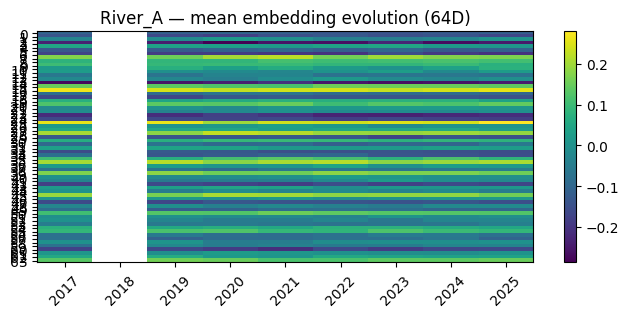


PROCESSING: River_B
Raster bands: 576

Bands per year:
2017 → 64
2018 → 64
2019 → 64
2020 → 64
2021 → 64
2022 → 64
2023 → 64
2024 → 64
2025 → 64

Final years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Mean matrix shape: (9, 64)


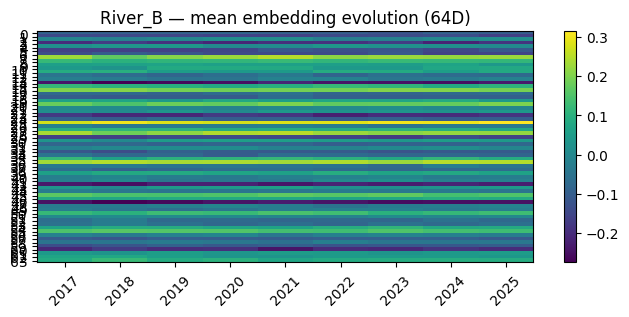


PROCESSING: River_C
Raster bands: 576

Bands per year:
2017 → 64
2018 → 64
2019 → 64
2020 → 64
2021 → 64
2022 → 64
2023 → 64
2024 → 64
2025 → 64


[codecarbon INFO @ 18:26:53] Energy consumed for RAM : 0.000333 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:26:53] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:26:53] Energy consumed for All CPU : 0.001416 kWh
[codecarbon INFO @ 18:26:53] 0.001750 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:26:53] 0.002023 g.CO2eq/s mean an estimation of 63.785170927092416 kg.CO2eq/year
[codecarbon INFO @ 18:27:08] Energy consumed for RAM : 0.000375 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:27:08] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:27:08] Energy consumed for All CPU : 0.001593 kWh
[codecarbon INFO @ 18:27:08] 0.001968 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:27:23] Energy consumed for RAM : 0.000416 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:27:23] Delta energy consumed for CP


Final years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Mean matrix shape: (9, 64)


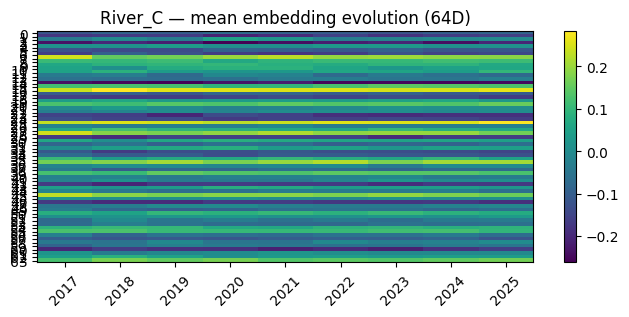


SUMMARY
River_A
  years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
  shape: (9, 64)
River_B
  years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
  shape: (9, 64)
River_C
  years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
  shape: (9, 64)


In [4]:
import rasterio
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# ------------------------------------------------------------
# 1. INPUT PATHS
# ------------------------------------------------------------
paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif"
}

river_results = {}

# ------------------------------------------------------------
# 2. PROCESS EACH RIVER (SAFE + CORRECTED INDEXING)
# ------------------------------------------------------------
for river_name, path in paths.items():

    print("\n====================================================")
    print("PROCESSING:", river_name)
    print("====================================================")

    with rasterio.open(path) as src:

        names = list(src.descriptions)
        print("Raster bands:", src.count)

        # ----------------------------------------------------
        # EXTRACT YEARS
        # ----------------------------------------------------
        def extract_year(name):
            if name is None:
                return None
            m = re.search(r"_(\d{4})_", name)
            return int(m.group(1)) if m else None

        years = np.array([extract_year(n) for n in names])

        # ----------------------------------------------------
        # GROUP BANDS BY YEAR
        # ----------------------------------------------------
        year_groups = defaultdict(list)

        for i, y in enumerate(years):
            if y is not None:
                year_groups[y].append(i)

        print("\nBands per year:")
        for y in sorted(year_groups.keys()):
            print(y, "→", len(year_groups[y]))

        # ----------------------------------------------------
        # BUILD CLEAN YEARLY STACK (NO FULL RAM LOAD)
        # ----------------------------------------------------
        clean_years = []
        yearly_means = []

        for y in sorted(year_groups.keys()):

            idx = sorted(year_groups[y])

            # ------------------------------------------------
            # FIX 1: convert 0-based → 1-based indexing
            # ------------------------------------------------
            idx = [i + 1 for i in idx]

            # ------------------------------------------------
            # FIX 2: ensure valid raster band range
            # ------------------------------------------------
            idx = [i for i in idx if 1 <= i <= src.count]

            # ------------------------------------------------
            # enforce 64-band structure
            # ------------------------------------------------
            if len(idx) < 64:
                print(f"Skipping incomplete year {y} ({len(idx)} bands)")
                continue

            idx = idx[:64]

            # ------------------------------------------------
            # READ ONLY REQUIRED BANDS
            # ------------------------------------------------
            block = src.read(idx)  # (64, H, W)

            flat = block.reshape(64, -1)

            mean_vec = np.nanmean(flat, axis=1)

            yearly_means.append(mean_vec)
            clean_years.append(y)

        yearly_means = np.array(yearly_means)

        print("\nFinal years:", clean_years)
        print("Mean matrix shape:", yearly_means.shape)

        # ----------------------------------------------------
        # STORE RESULTS
        # ----------------------------------------------------
        river_results[river_name] = {
            "years": np.array(clean_years),
            "means": yearly_means
        }

        # ----------------------------------------------------
        # QUICK VISUAL CHECK
        # ----------------------------------------------------
        if len(yearly_means) > 0:

            plt.figure(figsize=(8,3))
            plt.imshow(yearly_means.T, aspect='auto', cmap='viridis')
            plt.yticks(range(64))
            plt.xticks(range(len(clean_years)), clean_years, rotation=45)
            plt.title(f"{river_name} — mean embedding evolution (64D)")
            plt.colorbar()
            plt.show()

# ------------------------------------------------------------
# 3. SUMMARY
# ------------------------------------------------------------
print("\n====================================================")
print("SUMMARY")
print("====================================================")

for k, v in river_results.items():
    print(k)
    print("  years:", v["years"])
    print("  shape:", v["means"].shape)


River_A
Years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
Shape: (9, 64)

River_B
Years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
Shape: (9, 64)

River_C
Years: [2017 2018 2019 2020 2021 2022 2023 2024 2025]
Shape: (9, 64)


[codecarbon INFO @ 18:30:38] Energy consumed for RAM : 0.000958 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:30:38] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:30:38] Energy consumed for All CPU : 0.004072 kWh
[codecarbon INFO @ 18:30:38] 0.005030 kWh of electricity and 0.000000 L of water were used since the beginning.


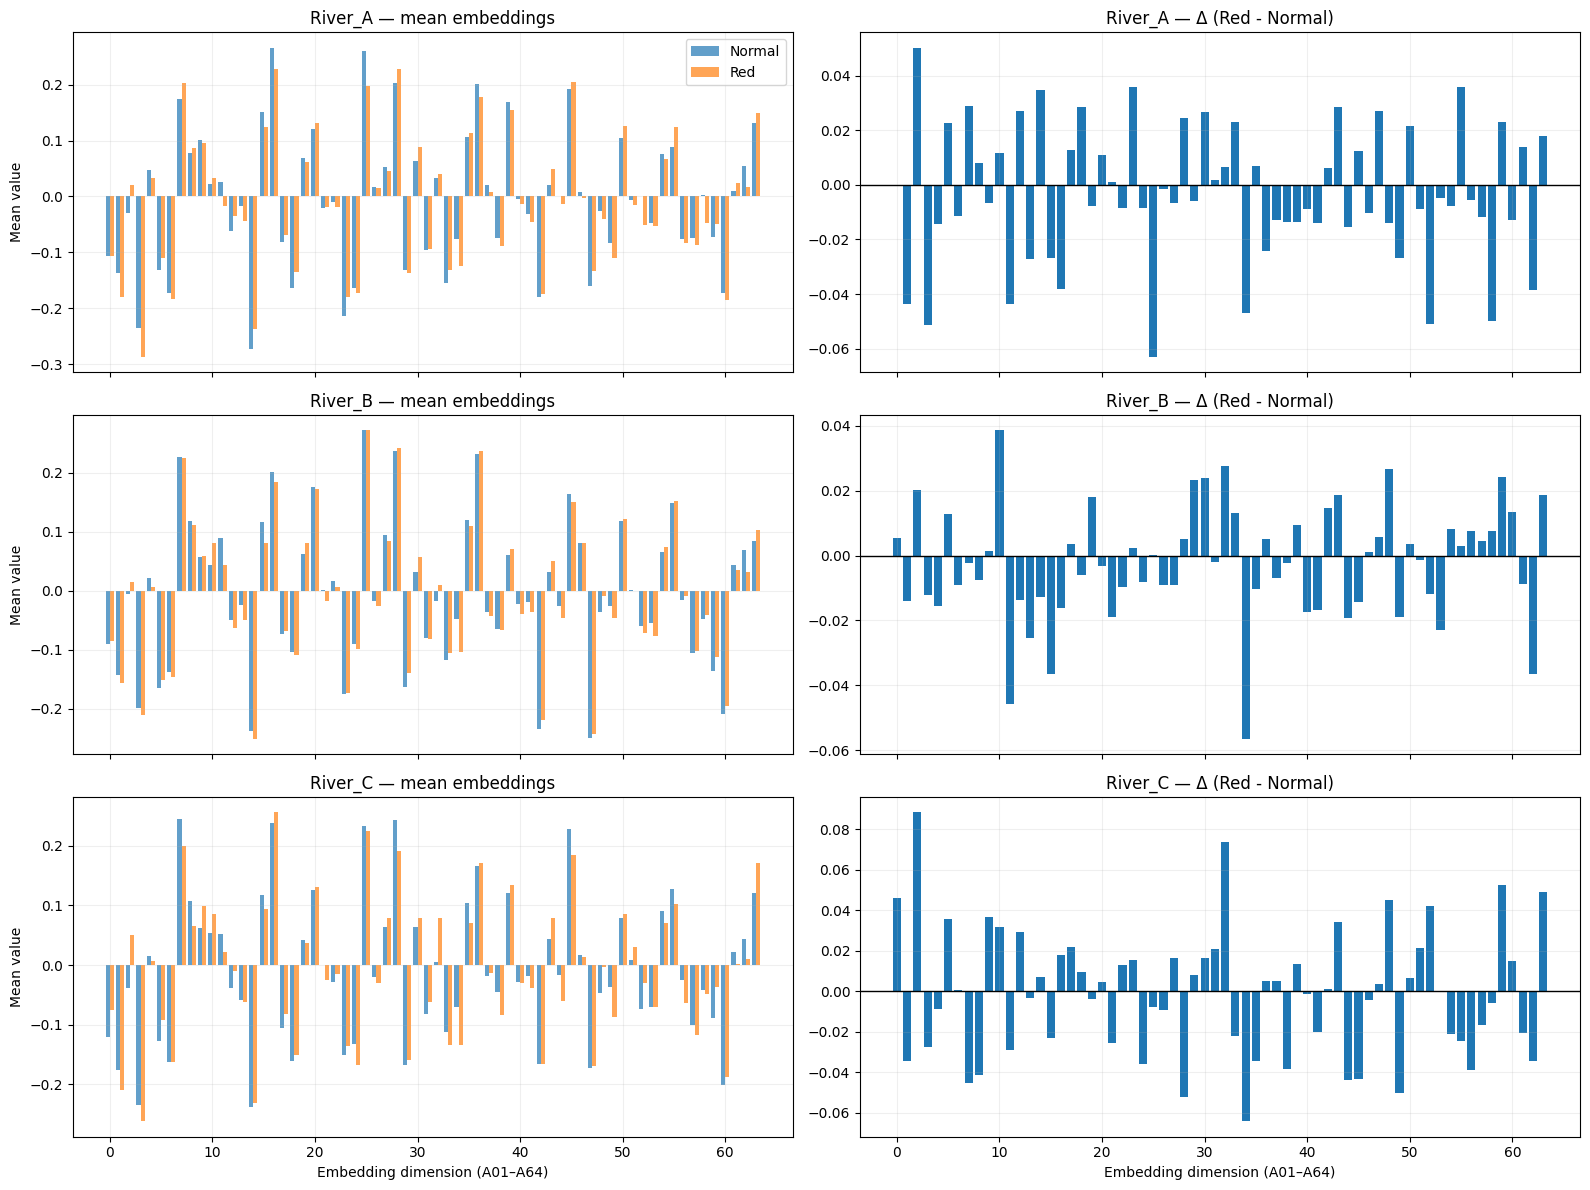


SUMMARY METRICS

 River_A
  ||Δ||: 0.20168142386175866
  Top dims: ['A26', 'A04', 'A53', 'A03', 'A59', 'A35', 'A02']

 River_B
  ||Δ||: 0.1427879230223749
  Top dims: ['A35', 'A12', 'A11', 'A16', 'A63', 'A33', 'A49']

 River_C
  ||Δ||: 0.2529455413423738
  Top dims: ['A03', 'A33', 'A35', 'A60', 'A29', 'A50', 'A64']


In [5]:
#### Plot Changes

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# MULTI-RIVER EMBEDDING CHANGE COMPARISON (A, B, C)
# expects:
# river_results = {
#   "River_A": {"years": ..., "means": (n,64)},
#   "River_B": {...},
#   "River_C": {...}
# }
# ------------------------------------------------------------

rivers = ["River_A", "River_B", "River_C"]

# ------------------------------------------------------------
# USER-DEFINED REGIMES (EDIT THESE)
# ------------------------------------------------------------
normal_years = np.array([2017])
red_years = np.array([2020])

dims = np.arange(64)

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

# ------------------------------------------------------------
# LOOP OVER RIVERS
# ------------------------------------------------------------
for r_i, river_name in enumerate(rivers):

    years = np.array(river_results[river_name]["years"])
    means = np.array(river_results[river_name]["means"])

    print("\n==============================")
    print(river_name)
    print("Years:", years)
    print("Shape:", means.shape)

    # --------------------------------------------------------
    # MASK REGIMES
    # --------------------------------------------------------
    normal_mask = np.isin(years, normal_years)
    red_mask = np.isin(years, red_years)

    if np.sum(normal_mask) == 0 or np.sum(red_mask) == 0:
        print("Skipping (missing regime years)")
        continue

    # --------------------------------------------------------
    # COMPUTE MEANS
    # --------------------------------------------------------
    normal_vec = np.nanmean(means[normal_mask], axis=0)
    red_vec = np.nanmean(means[red_mask], axis=0)

    delta = red_vec - normal_vec

    # --------------------------------------------------------
    # PLOT 1: SIDE-BY-SIDE COMPARISON
    # --------------------------------------------------------
    ax = axes[r_i, 0]

    ax.bar(dims - 0.2, normal_vec, width=0.4, label="Normal", alpha=0.7)
    ax.bar(dims + 0.2, red_vec, width=0.4, label="Red", alpha=0.7)

    ax.set_title(f"{river_name} — mean embeddings")
    ax.set_ylabel("Mean value")
    ax.grid(alpha=0.2)

    if r_i == 0:
        ax.legend()

    # --------------------------------------------------------
    # PLOT 2: DELTA
    # --------------------------------------------------------
    ax2 = axes[r_i, 1]

    ax2.bar(dims, delta)

    ax2.axhline(0, color="black", linewidth=1)
    ax2.set_title(f"{river_name} — Δ (Red - Normal)")
    ax2.grid(alpha=0.2)

# ------------------------------------------------------------
# GLOBAL LABELS
# ------------------------------------------------------------
axes[2, 0].set_xlabel("Embedding dimension (A01–A64)")
axes[2, 1].set_xlabel("Embedding dimension (A01–A64)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# OPTIONAL: SUMMARY NUMBERS
# ------------------------------------------------------------
print("\n==============================")
print("SUMMARY METRICS")
print("==============================")

for river_name in rivers:

    years = np.array(river_results[river_name]["years"])
    means = np.array(river_results[river_name]["means"])

    normal_mask = np.isin(years, normal_years)
    red_mask = np.isin(years, red_years)

    if np.sum(normal_mask) == 0 or np.sum(red_mask) == 0:
        continue

    normal_vec = np.nanmean(means[normal_mask], axis=0)
    red_vec = np.nanmean(means[red_mask], axis=0)
    delta = red_vec - normal_vec

    print("\n", river_name)
    print("  ||Δ||:", np.linalg.norm(delta))

    top = np.argsort(np.abs(delta))[::-1][:7]
    print("  Top dims:", [f"A{i+1:02d}" for i in top])

River_A: removed 1 bad rows
River_B: removed 0 bad rows
River_C: removed 0 bad rows

Final PCA shape: (26, 64)
Explained variance: [0.36305834 0.17501914]


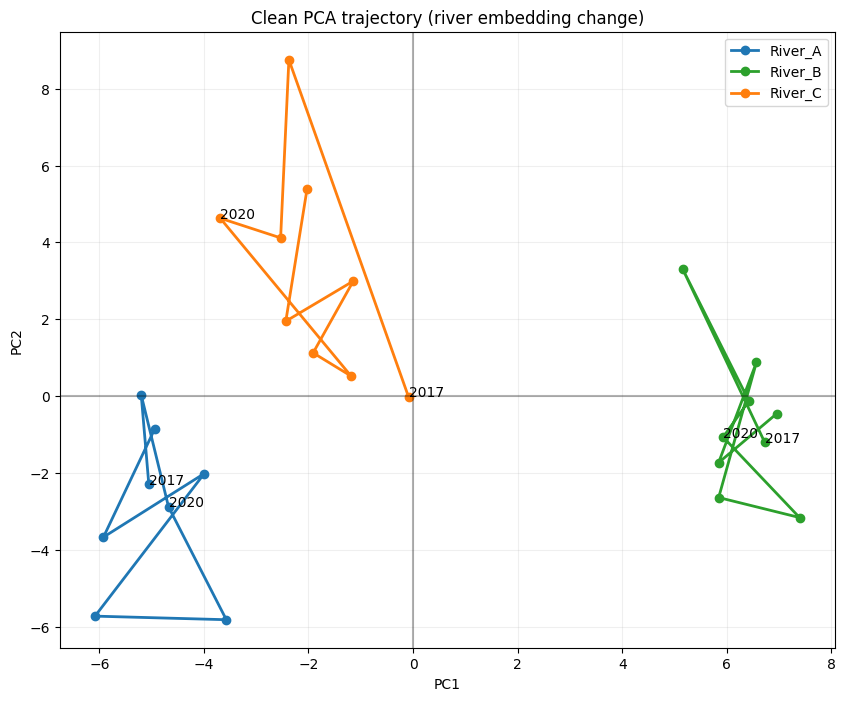

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

rivers = ["River_A", "River_B", "River_C"]

all_data = []
all_labels = []
all_years = []

for r in rivers:

    years = np.array(river_results[r]["years"])
    means = np.array(river_results[r]["means"], dtype=np.float64)

    # --------------------------------------------------------
    # KEEP ONLY VALID ROWS
    # --------------------------------------------------------
    valid_mask = np.isfinite(means).all(axis=1)

    years_clean = years[valid_mask]
    means_clean = means[valid_mask]

    print(f"{r}: removed {len(years) - len(years_clean)} bad rows")

    all_data.append(means_clean)
    all_labels.extend([r] * len(years_clean))
    all_years.extend(years_clean)

all_data = np.vstack(all_data)
all_labels = np.array(all_labels)
all_years = np.array(all_years)

print("\nFinal PCA shape:", all_data.shape)

# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------
X = StandardScaler().fit_transform(all_data)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance:", pca.explained_variance_ratio_)

# ------------------------------------------------------------
# PLOT TRAJECTORIES
# ------------------------------------------------------------
plt.figure(figsize=(10,8))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange"
}

for r in rivers:

    mask = (all_labels == r)
    yrs = all_years[mask]
    coords = X_pca[mask]

    order = np.argsort(yrs)
    yrs = yrs[order]
    coords = coords[order]

    plt.plot(coords[:,0], coords[:,1],
             marker="o",
             linewidth=2,
             label=r,
             color=colors[r])

    for i, y in enumerate(yrs):
        if y in [2017, 2020]:
            plt.text(coords[i,0], coords[i,1], str(y), fontsize=10)

plt.axhline(0, alpha=0.3, color="black")
plt.axvline(0, alpha=0.3, color="black")

plt.title("Clean PCA trajectory (river embedding change)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Explained variance: [0.44488321 0.27344431]


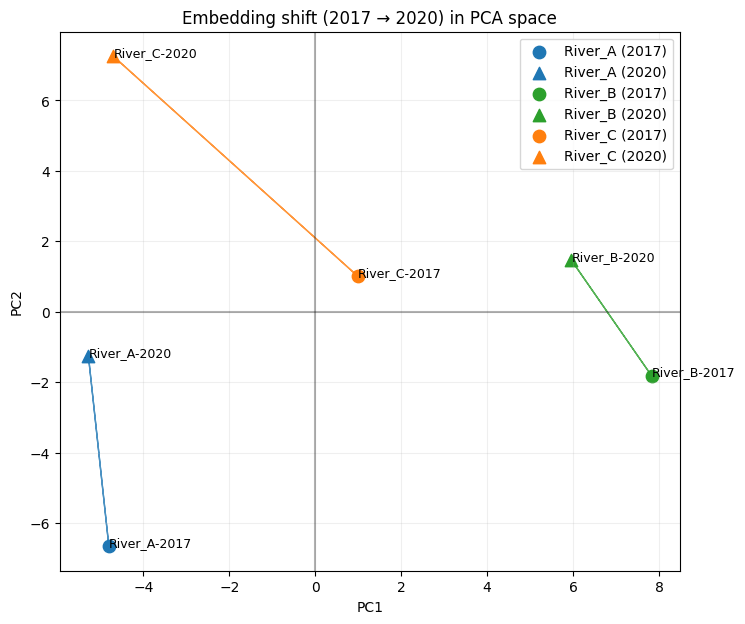

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

rivers = ["River_A", "River_B", "River_C"]

results = {}
dims = np.arange(64)

# ------------------------------------------------------------
# 1. EXTRACT 2017 / 2020 MEANS
# ------------------------------------------------------------
for r in rivers:

    years = np.array(river_results[r]["years"])
    means = np.array(river_results[r]["means"], dtype=np.float64)

    m2017 = (years == 2017)
    m2020 = (years == 2020)

    if np.sum(m2017) == 0 or np.sum(m2020) == 0:
        print(f"{r}: missing 2017 or 2020")
        continue

    v2017 = np.nanmean(means[m2017], axis=0)
    v2020 = np.nanmean(means[m2020], axis=0)

    results[r] = {
        "2017": v2017,
        "2020": v2020
    }

# ------------------------------------------------------------
# 2. PCA SPACE (ONLY 6 POINTS TOTAL)
# ------------------------------------------------------------
X = []
labels = []
r_labels = []

for r in results:

    X.append(results[r]["2017"])
    X.append(results[r]["2020"])

    labels.append("2017")
    labels.append("2020")

    r_labels.append(r)
    r_labels.append(r)

X = np.array(X)

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

# ------------------------------------------------------------
# 3. PLOT WITH ARROWS (COLOURED BY RIVER)
# ------------------------------------------------------------
plt.figure(figsize=(8,7))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange"
}

for r in results:

    idx_2017 = list(results.keys()).index(r) * 2
    idx_2020 = idx_2017 + 1

    x1, y1 = X_pca[idx_2017]
    x2, y2 = X_pca[idx_2020]

    c = colors[r]

    # points
    plt.scatter(x1, y1, color=c, s=80, label=f"{r} (2017)")
    plt.scatter(x2, y2, color=c, s=80, marker="^", label=f"{r} (2020)")

    # arrow
    plt.arrow(
        x1, y1,
        x2 - x1,
        y2 - y1,
        color=c,
        head_width=0.03,
        length_includes_head=True,
        alpha=0.8
    )

    # labels
    plt.text(x1, y1, f"{r}-2017", fontsize=9)
    plt.text(x2, y2, f"{r}-2020", fontsize=9)

# ------------------------------------------------------------
# 4. STYLING
# ------------------------------------------------------------
plt.axhline(0, color="black", alpha=0.3)
plt.axvline(0, color="black", alpha=0.3)

plt.title("Embedding shift (2017 → 2020) in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)

# clean legend (avoid duplicates)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="best")

plt.show()


Processing River_A


[codecarbon INFO @ 20:59:09] Energy consumed for RAM : 0.025697 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:59:09] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:59:09] Energy consumed for All CPU : 0.109228 kWh
[codecarbon INFO @ 20:59:09] 0.134924 kWh of electricity and 0.000000 L of water were used since the beginning.


River_A: pixels = 1382

Processing River_B
River_B: pixels = 495

Processing River_C


[codecarbon INFO @ 20:59:24] Energy consumed for RAM : 0.025738 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:59:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:59:24] Energy consumed for All CPU : 0.109405 kWh
[codecarbon INFO @ 20:59:24] 0.135143 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:59:39] Energy consumed for RAM : 0.025780 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:59:39] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:59:39] Energy consumed for All CPU : 0.109582 kWh
[codecarbon INFO @ 20:59:39] 0.135361 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:59:54] Energy consumed for RAM : 0.025821 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:59:54] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:59:54] Energy consumed for All CPU

River_C: pixels = 8430

Processing Control_1


[codecarbon INFO @ 21:00:09] Energy consumed for RAM : 0.025863 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:00:09] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:00:09] Energy consumed for All CPU : 0.109936 kWh
[codecarbon INFO @ 21:00:09] 0.135799 kWh of electricity and 0.000000 L of water were used since the beginning.


Control_1: pixels = 4163

Processing Control_2
Control_2: pixels = 536

Processing Control_3
Control_3: pixels = 748

Balanced sample size per river: 495

Final balanced dataset: (2970, 64)

Explained variance: [0.25322386 0.14697354]

 Rusting axis (64D):
[ 0.19709898 -0.03865408  0.18107016  0.03345251  0.02145754  0.06779412
  0.0351043  -0.20888423 -0.18225578  0.12351102  0.06956632  0.07984884
  0.0850926   0.16091438 -0.06541032 -0.02793541  0.21485567  0.10116656
 -0.03801154 -0.031787    0.04807174 -0.10868588  0.15688222  0.01430637
 -0.17298799  0.11402414 -0.07624721  0.11052869 -0.223264    0.03896285
 -0.06672854  0.11981109  0.2028661  -0.16029755 -0.08253386 -0.19952916
  0.12956501  0.13527342 -0.16118861  0.03718957  0.06827413 -0.08667274
 -0.02823717  0.06440267 -0.15107698 -0.18535182  0.02740928 -0.10286766
  0.15383927 -0.09130161 -0.09254686  0.14616319  0.22805751  0.10960123
 -0.0975588  -0.17766521 -0.170486   -0.10530972  0.05928491  0.13275693
  0.12820678 

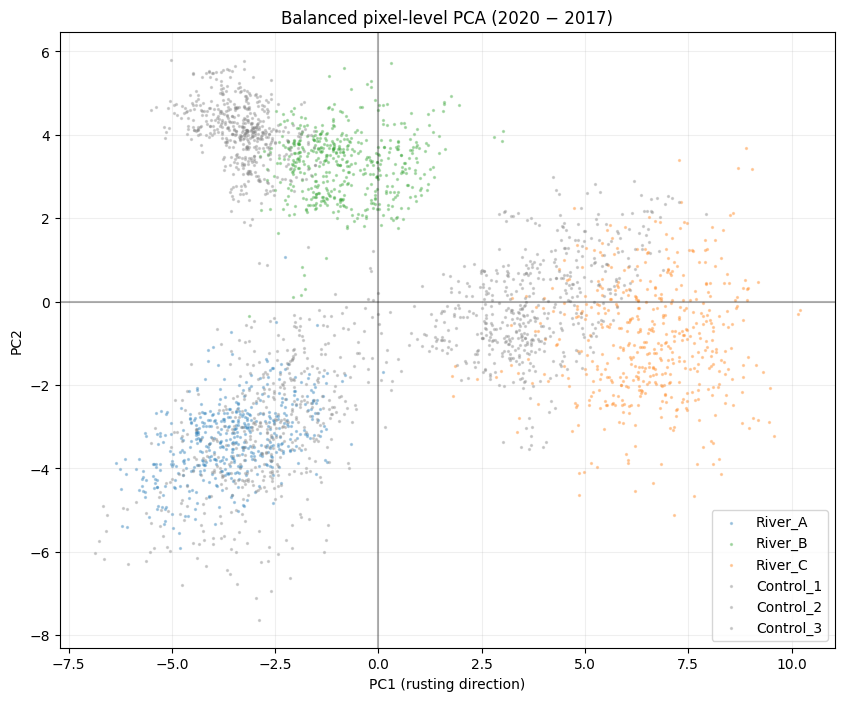


===== RIVER STATISTICS =====
River_A: mean=-3.528423, std=1.162625
River_B: mean=-0.801672, std=1.077826
River_C: mean=6.561668, std=1.389012
Control_1: mean=-2.694409, std=1.397578
Control_2: mean=-3.307783, std=0.718042
Control_3: mean=3.770619, std=1.326507


In [33]:
## PCA on deltas
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import defaultdict
import re

# ------------------------------------------------------------
# INPUT PATHS
# ------------------------------------------------------------
paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif",
    "Control_1": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_1.tif",
    "Control_2": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_2.tif",
    "Control_3": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_4.tif"
}

rivers = list(paths.keys())

river_pixels = {}
river_labels = {}

# ------------------------------------------------------------
# 1. EXTRACT PIXEL-LEVEL DELTAS PER RIVER
# ------------------------------------------------------------
for r, path in paths.items():

    print(f"\nProcessing {r}")

    with rasterio.open(path) as src:

        names = list(src.descriptions)

        def extract_year(name):
            if name is None:
                return None
            m = re.search(r"_(\d{4})_", name)
            return int(m.group(1)) if m else None

        years = np.array([extract_year(n) for n in names])

        groups = defaultdict(list)
        for i, y in enumerate(years):
            if y is not None:
                groups[y].append(i)

        if 2017 not in groups or 2020 not in groups:
            print(f"{r}: missing 2017 or 2020")
            continue

        idx17 = sorted(groups[2017])[:64]
        idx20 = sorted(groups[2020])[:64]

        idx17 = [i + 1 for i in idx17 if i + 1 <= src.count]
        idx20 = [i + 1 for i in idx20 if i + 1 <= src.count]

        img17 = src.read(idx17)
        img20 = src.read(idx20)

        delta = img20 - img17   # (64, H, W)

        X = delta.reshape(64, -1).T  # (pixels, 64)

        valid = np.isfinite(X).all(axis=1)
        X = X[valid]

        river_pixels[r] = X

        print(f"{r}: pixels = {X.shape[0]}")

# ------------------------------------------------------------
# 2. BALANCE SAMPLE SIZE ACROSS RIVERS
# ------------------------------------------------------------
min_n = min([v.shape[0] for v in river_pixels.values()])

print("\nBalanced sample size per river:", min_n)

X_all = []
labels = []

for r in rivers:

    X = river_pixels[r]

    # random subsample
    idx = np.random.choice(X.shape[0], min_n, replace=False)

    X_bal = X[idx]

    X_all.append(X_bal)
    labels.extend([r] * min_n)

X_all = np.vstack(X_all)
labels = np.array(labels)

print("\nFinal balanced dataset:", X_all.shape)

# ------------------------------------------------------------
# 3. STANDARDISE
# ------------------------------------------------------------
X_all = StandardScaler().fit_transform(X_all)

# ------------------------------------------------------------
# 4. PCA
# ------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

print("\nExplained variance:", pca.explained_variance_ratio_)

rusting_axis = pca.components_[0]
print("\n Rusting axis (64D):")
print(rusting_axis)

# ------------------------------------------------------------
# 5. VISUALISATION
# ------------------------------------------------------------
plt.figure(figsize=(10,8))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange",
    "Control_1": "tab:grey",
    "Control_2": "tab:grey",
    "Control_3": "tab:grey"
}

for r in rivers:
    mask = (labels == r)

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=2,
        alpha=0.3,
        label=r,
        color=colors[r]
    )

plt.axhline(0, color="black", alpha=0.3)
plt.axvline(0, color="black", alpha=0.3)

plt.title("Balanced pixel-level PCA (2020 − 2017)")
plt.xlabel("PC1 (rusting direction)")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

# ------------------------------------------------------------
# 6. RIVER PROJECTIONS
# ------------------------------------------------------------
print("\n===== RIVER STATISTICS =====")

for r in rivers:
    mask = (labels == r)
    proj = X_pca[mask, 0]

    print(f"{r}: mean={proj.mean():.6f}, std={proj.std():.6f}")


Processing River_A


[codecarbon INFO @ 21:16:54] Energy consumed for RAM : 0.028653 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:16:54] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:16:54] Energy consumed for All CPU : 0.121797 kWh
[codecarbon INFO @ 21:16:54] 0.150450 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:16:54] 0.002022 g.CO2eq/s mean an estimation of 63.755622123422675 kg.CO2eq/year
[codecarbon INFO @ 21:17:09] Energy consumed for RAM : 0.028695 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:17:09] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:17:09] Energy consumed for All CPU : 0.121974 kWh
[codecarbon INFO @ 21:17:09] 0.150669 kWh of electricity and 0.000000 L of water were used since the beginning.


River_A: pixels = 1382

Processing River_B
River_B: pixels = 495

Processing River_C


[codecarbon INFO @ 21:17:24] Energy consumed for RAM : 0.028737 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:17:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:17:24] Energy consumed for All CPU : 0.122151 kWh
[codecarbon INFO @ 21:17:24] 0.150887 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:17:39] Energy consumed for RAM : 0.028778 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:17:39] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:17:39] Energy consumed for All CPU : 0.122328 kWh
[codecarbon INFO @ 21:17:39] 0.151106 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:17:54] Energy consumed for RAM : 0.028820 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:17:54] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:17:54] Energy consumed for All CPU

River_C: pixels = 8430

Processing Control_1


[codecarbon INFO @ 21:18:09] Energy consumed for RAM : 0.028862 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:18:09] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:18:09] Energy consumed for All CPU : 0.122682 kWh
[codecarbon INFO @ 21:18:09] 0.151544 kWh of electricity and 0.000000 L of water were used since the beginning.


Control_1: pixels = 4163

Processing Control_2
Control_2: pixels = 536

Processing Control_3
Control_3: pixels = 748

Balanced sample size per river: 495

Control shape: (1485, 64)
Rust shape: (1485, 64)

Explained variance: [0.30428523 0.14926352]


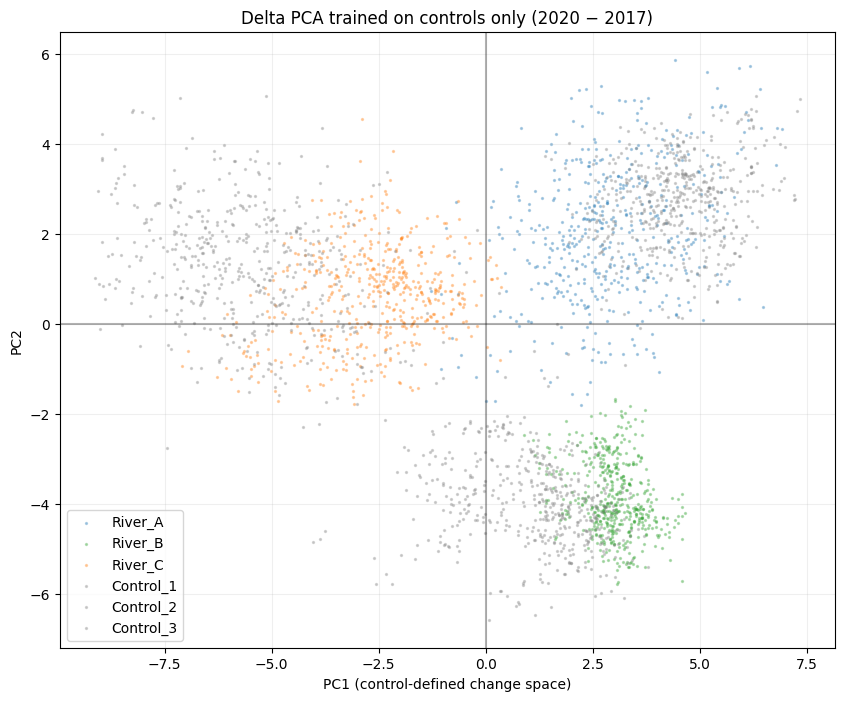


===== RIVER STATISTICS (CONTROL PCA SPACE) =====
River_A: mean=2.910746, std=1.471795
River_B: mean=2.995427, std=0.639605
River_C: mean=-2.627752, std=1.363259
Control_1: mean=4.484735, std=1.110822
Control_2: mean=1.082449, std=1.364349
Control_3: mean=-5.567184, std=1.746229


In [35]:
## PCA on deltas, only on controls:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import defaultdict
import re

# ------------------------------------------------------------
# INPUT PATHS
# ------------------------------------------------------------
paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif",
    "Control_1": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_1.tif",
    "Control_2": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_2.tif",
    "Control_3": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_4.tif"
}

rivers = list(paths.keys())

control_rivers = ["Control_1", "Control_2", "Control_3"]
rusting_rivers = ["River_A", "River_B", "River_C"]

river_pixels = {}
river_labels = {}

# ------------------------------------------------------------
# 1. EXTRACT PIXEL-LEVEL DELTAS PER RIVER
# ------------------------------------------------------------
for r, path in paths.items():

    print(f"\nProcessing {r}")

    with rasterio.open(path) as src:

        names = list(src.descriptions)

        def extract_year(name):
            if name is None:
                return None
            m = re.search(r"_(\d{4})_", name)
            return int(m.group(1)) if m else None

        years = np.array([extract_year(n) for n in names])

        groups = defaultdict(list)
        for i, y in enumerate(years):
            if y is not None:
                groups[y].append(i)

        if 2017 not in groups or 2020 not in groups:
            print(f"{r}: missing 2017 or 2020")
            continue

        idx17 = sorted(groups[2017])[:64]
        idx20 = sorted(groups[2020])[:64]

        idx17 = [i + 1 for i in idx17 if i + 1 <= src.count]
        idx20 = [i + 1 for i in idx20 if i + 1 <= src.count]

        img17 = src.read(idx17)
        img20 = src.read(idx20)

        delta = img20 - img17   # (64, H, W)

        X = delta.reshape(64, -1).T  # (pixels, 64)

        valid = np.isfinite(X).all(axis=1)
        X = X[valid]

        river_pixels[r] = X

        print(f"{r}: pixels = {X.shape[0]}")

# ------------------------------------------------------------
# 2. BALANCE SAMPLE SIZE ACROSS RIVERS
# ------------------------------------------------------------
min_n = min([v.shape[0] for v in river_pixels.values()])

print("\nBalanced sample size per river:", min_n)

X_control = []
X_rust = []
labels = []

for r in rivers:

    X = river_pixels[r]

    idx = np.random.choice(X.shape[0], min_n, replace=False)
    X_bal = X[idx]

    if r in control_rivers:
        X_control.append(X_bal)
    else:
        X_rust.append(X_bal)

    labels.extend([r] * min_n)

X_control = np.vstack(X_control)
X_rust = np.vstack(X_rust)

X_all = np.vstack([X_control, X_rust])
labels = np.array(labels)

print("\nControl shape:", X_control.shape)
print("Rust shape:", X_rust.shape)

# ------------------------------------------------------------
# 3. STANDARDISE (FIT ONLY ON CONTROLS)
# ------------------------------------------------------------
scaler = StandardScaler()
scaler.fit(X_rust)

X_all_scaled = scaler.transform(X_all)

# ------------------------------------------------------------
# 4. PCA FIT (CONTROLS ONLY)
# ------------------------------------------------------------
pca = PCA(n_components=2)
pca.fit(scaler.transform(X_rust))

X_pca = pca.transform(X_all_scaled)

print("\nExplained variance:", pca.explained_variance_ratio_)

# ------------------------------------------------------------
# 5. VISUALISATION
# ------------------------------------------------------------
plt.figure(figsize=(10,8))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange",
    "Control_1": "grey",
    "Control_2": "grey",
    "Control_3": "grey"
}

for r in rivers:

    mask = (labels == r)

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=2,
        alpha=0.3,
        color=colors[r],
        label=r
    )

plt.axhline(0, color="black", alpha=0.3)
plt.axvline(0, color="black", alpha=0.3)

plt.title("Delta PCA trained on controls only (2020 − 2017)")
plt.xlabel("PC1 (control-defined change space)")
plt.ylabel("PC2")

plt.legend()
plt.grid(alpha=0.2)
plt.show()

# ------------------------------------------------------------
# 6. RIVER STATISTICS IN CONTROL SPACE
# ------------------------------------------------------------
print("\n===== RIVER STATISTICS (CONTROL PCA SPACE) =====")

for r in rivers:
    mask = (labels == r)
    proj = X_pca[mask, 0]

    print(f"{r}: mean={proj.mean():.6f}, std={proj.std():.6f}")

In [4]:
### PCA on all pixels, plotting change vectors


Processing River_A


[codecarbon INFO @ 20:53:24] Energy consumed for RAM : 0.024739 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:53:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:53:24] Energy consumed for All CPU : 0.105157 kWh
[codecarbon INFO @ 20:53:24] 0.129896 kWh of electricity and 0.000000 L of water were used since the beginning.


River_A: pixels used = 1382

Processing River_B
River_B: pixels used = 495

Processing River_C


[codecarbon INFO @ 20:53:39] Energy consumed for RAM : 0.024781 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:53:39] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:53:39] Energy consumed for All CPU : 0.105334 kWh
[codecarbon INFO @ 20:53:39] 0.130115 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:53:54] Energy consumed for RAM : 0.024822 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:53:54] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:53:54] Energy consumed for All CPU : 0.105511 kWh
[codecarbon INFO @ 20:53:54] 0.130334 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:54:09] Energy consumed for RAM : 0.024864 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:54:09] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:54:09] Energy consumed for All CPU

River_C: pixels used = 8430

Global dataset shape: (20614, 64)
Balanced samples per (river, year): 495
Balanced dataset: (2970, 64)

Explained variance ratio: [0.25348246 0.17222294]


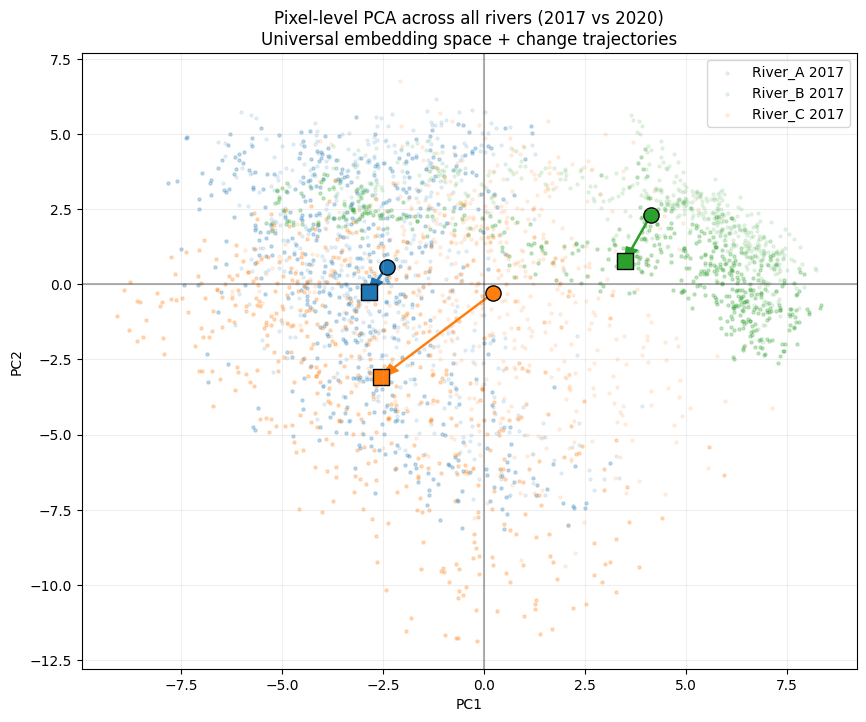

In [29]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import defaultdict
import re

# ============================================================
# 1. INPUT PATHS
# ============================================================
paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif"
}

rivers = list(paths.keys())

# Storage for pixel-level samples
data_blocks = []
labels_river = []
labels_year = []

# ============================================================
# 2. LOAD PIXELS (NO MEANS, NO DELTAS)
# ============================================================
for r, path in paths.items():

    print(f"\nProcessing {r}")

    with rasterio.open(path) as src:

        names = list(src.descriptions)

        def extract_year(name):
            if name is None:
                return None
            m = re.search(r"_(\d{4})_", name)
            return int(m.group(1)) if m else None

        years = np.array([extract_year(n) for n in names])

        groups = defaultdict(list)
        for i, y in enumerate(years):
            if y is not None:
                groups[y].append(i)

        # only years of interest
        if 2017 not in groups or 2020 not in groups:
            print(f"{r}: missing 2017 or 2020")
            continue

        idx17 = [i + 1 for i in sorted(groups[2017])[:64] if i + 1 <= src.count]
        idx20 = [i + 1 for i in sorted(groups[2020])[:64] if i + 1 <= src.count]

        img17 = src.read(idx17)  # (64, H, W)
        img20 = src.read(idx20)

        # ========================================================
        # FLATTEN TO PIXELS (NO AGGREGATION)
        # ========================================================
        X17 = img17.reshape(64, -1).T
        X20 = img20.reshape(64, -1).T

        # keep only pixels valid in BOTH years
        valid = np.isfinite(X17).all(axis=1) & np.isfinite(X20).all(axis=1)

        X17 = X17[valid]
        X20 = X20[valid]

        print(f"{r}: pixels used = {X17.shape[0]}")

        # store
        data_blocks.append(X17)
        data_blocks.append(X20)

        labels_river += [r] * len(X17)
        labels_year += [2017] * len(X17)

        labels_river += [r] * len(X20)
        labels_year += [2020] * len(X20)

# ============================================================
# 3. STACK GLOBAL DATASET
# ============================================================
X = np.vstack(data_blocks)
labels_river = np.array(labels_river)
labels_year = np.array(labels_year)

print("\nGlobal dataset shape:", X.shape)

# ============================================================
# 4. BALANCE SAMPLE SIZE (PER RIVER + YEAR)
# ============================================================
min_n = min([
    np.sum((labels_river == r) & (labels_year == y))
    for r in rivers
    for y in [2017, 2020]
])

print("Balanced samples per (river, year):", min_n)

balanced_X = []
balanced_river = []
balanced_year = []

for r in rivers:
    for y in [2017, 2020]:

        mask = (labels_river == r) & (labels_year == y)
        X_sub = X[mask]

        if len(X_sub) == 0:
            continue

        idx = np.random.choice(len(X_sub), min_n, replace=False)

        balanced_X.append(X_sub[idx])
        balanced_river += [r] * min_n
        balanced_year += [y] * min_n

X_bal = np.vstack(balanced_X)
balanced_river = np.array(balanced_river)
balanced_year = np.array(balanced_year)

print("Balanced dataset:", X_bal.shape)

# ============================================================
# 5. STANDARDISE
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bal)

# ============================================================
# 6. PCA ON ALL PIXELS (BOTH YEARS, ALL RIVERS)
# ============================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)

# ============================================================
# 7. VISUALISATION
# ============================================================
plt.figure(figsize=(10, 8))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange"
}

# scatter by river + year
for r in rivers:
    for y, alpha in [(2017, 0.1), (2020, 0.25)]:

        mask = (balanced_river == r) & (balanced_year == y)

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=5,
            alpha=alpha,
            color=colors[r],
            label=f"{r} {y}" if y == 2017 else None
        )

# ============================================================
# MEAN SHIFT ARROWS (in PCA space)
# ============================================================
for r in rivers:

    p17 = X_pca[(balanced_river == r) & (balanced_year == 2017)]
    p20 = X_pca[(balanced_river == r) & (balanced_year == 2020)]

    if len(p17) == 0 or len(p20) == 0:
        continue

    m17 = p17.mean(axis=0)
    m20 = p20.mean(axis=0)

    plt.arrow(
        m17[0], m17[1],
        m20[0] - m17[0],
        m20[1] - m17[1],
        color=colors[r],
        width=0.03,
        head_width=0.3,
        length_includes_head=True
    )

    plt.scatter(m17[0], m17[1], color=colors[r], marker='o', s=120, edgecolor='black')
    plt.scatter(m20[0], m20[1], color=colors[r], marker='s', s=120, edgecolor='black')

# ============================================================
# FINAL STYLE
# ============================================================
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Pixel-level PCA across all rivers (2017 vs 2020)\nUniversal embedding space + change trajectories")

plt.grid(alpha=0.2)
plt.legend()
plt.show()


RIVER CHANGE DIRECTION ALIGNMENT (COSINE SIMILARITY)
River_A vs River_B: 0.9656
River_A vs River_C: 0.9954
River_B vs River_C: 0.9361

DIRECTION ANGLES IN PCA SPACE
River_A: angle = -127.44°
River_B: angle = -112.36°
River_C: angle = -132.95°


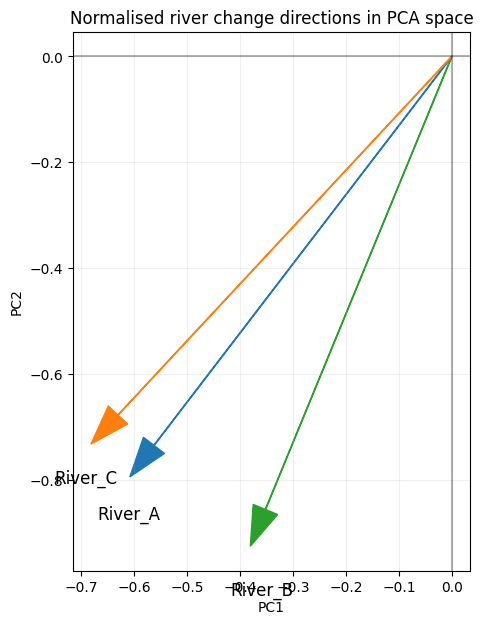

In [10]:
### Mean PCA change (from pixels)
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ASSUMES YOU HAVE ALREADY RUN THE PCA CELL AND HAVE:
# X_pca, balanced_river, balanced_year, rivers
# ============================================================

# ------------------------------------------------------------
# 1. COMPUTE MEAN DISPLACEMENT VECTORS PER RIVER
#    (in PCA space)
# ------------------------------------------------------------
mean_disp = {}

for r in rivers:

    p17 = X_pca[(balanced_river == r) & (balanced_year == 2017)]
    p20 = X_pca[(balanced_river == r) & (balanced_year == 2020)]

    if len(p17) == 0 or len(p20) == 0:
        continue

    v = p20.mean(axis=0) - p17.mean(axis=0)
    mean_disp[r] = v

# ------------------------------------------------------------
# 2. COSINE SIMILARITY BETWEEN RIVER CHANGE DIRECTIONS
# ------------------------------------------------------------
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

print("\n================================================")
print("RIVER CHANGE DIRECTION ALIGNMENT (COSINE SIMILARITY)")
print("================================================")

for i, r1 in enumerate(rivers):
    for r2 in rivers[i+1:]:
        if r1 in mean_disp and r2 in mean_disp:
            sim = cosine(mean_disp[r1], mean_disp[r2])
            print(f"{r1} vs {r2}: {sim:.4f}")

# ------------------------------------------------------------
# 3. ANGLE SUMMARY (INTERPRETABILITY)
# ------------------------------------------------------------
print("\n================================================")
print("DIRECTION ANGLES IN PCA SPACE")
print("================================================")

angles = {}

for r, v in mean_disp.items():
    angle = np.degrees(np.arctan2(v[1], v[0]))
    angles[r] = angle
    print(f"{r}: angle = {angle:.2f}°")

# ------------------------------------------------------------
# 4. VISUALISE NORMALISED DIRECTION VECTORS
# ------------------------------------------------------------
plt.figure(figsize=(7, 7))

origin = np.array([0.0, 0.0])

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange"
}

for r, v in mean_disp.items():

    v_norm = v / (np.linalg.norm(v) + 1e-12)

    plt.arrow(
        0, 0,
        v_norm[0], v_norm[1],
        head_width=0.05,
        length_includes_head=True,
        color=colors[r]
    )

    plt.text(
        v_norm[0]*1.1,
        v_norm[1]*1.1,
        r,
        fontsize=12
    )

plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)

plt.title("Normalised river change directions in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.gca().set_aspect('equal', adjustable='box')

plt.grid(alpha=0.2)
plt.show()

2. What PCA contributes (important)

Because PCA was fit on all pixels from all rivers + both years, the axes mean:

PC1 = direction of greatest variation across all river pixels and years
PC2 = second-most important independent variation

So your arrows are expressed in a shared coordinate system of dominant variability in the dataset.

That is what makes cross-river comparison valid.

3. How to interpret arrow direction

If arrows for different rivers:

Point in similar directions:

the dominant change in embeddings is shared
all rivers undergo a similar transformation in feature space
supports the idea of a “universal rusting direction”

This is the key result we are looking for

If they point in different directions: changes are river-specific
PCA structure is not dominated by a single “rusting axis”
or rusting is mixed with other environmental signals

4. What cosine similarity means

The cosine similarity computed:

cos(θ)=∣Δr1∣∣Δr2∣Δr1⋅Δr2


Interpretation:

~1.0 → almost identical change direction
~0.5–0.8 → partially shared trend
~0 → unrelated change
negative → opposite changes (very interesting, but rare in your case)

So if you see consistently high values across rivers, that is strong evidence of a shared structural shift.

5. What angles mean

The angle (in PC1–PC2 space):

gives a 2D projection of change direction
useful for visualization
but not the full 64D truth

Two rivers can have similar angles in 2D but still differ in higher PCs.

That’s why cosine similarity in 64D is actually more reliable than angle alone.


6. The test is effectively:

Do all rivers shift their pixel embedding distributions in the same direction in a shared feature space?

If yes, then:

this is not random noise
not river-specific morphology
but a systematic environmental transformation signal

7. Important caveat

PCA defines axes based on variance, not time.

So:

PCA does not “know” about 2017 vs 2020
it only gives you a coordinate system where structure is maximised

A strong alignment of arrows is actually non-trivial evidence

because it emerges after projecting into a purely variance-driven space.


Processing River_A


[codecarbon INFO @ 19:15:09] Energy consumed for RAM : 0.008371 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:15:09] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 19:15:09] Energy consumed for All CPU : 0.035583 kWh
[codecarbon INFO @ 19:15:09] 0.043954 kWh of electricity and 0.000000 L of water were used since the beginning.


River_A: pixels = 1382

Processing River_B
River_B: pixels = 495

Processing River_C


[codecarbon INFO @ 19:15:24] Energy consumed for RAM : 0.008413 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:15:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 19:15:24] Energy consumed for All CPU : 0.035760 kWh
[codecarbon INFO @ 19:15:24] 0.044173 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 19:15:39] Energy consumed for RAM : 0.008454 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:15:39] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 19:15:39] Energy consumed for All CPU : 0.035937 kWh
[codecarbon INFO @ 19:15:39] 0.044392 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 19:15:54] Energy consumed for RAM : 0.008496 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:15:54] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 19:15:54] Energy consumed for All CPU

River_C: pixels = 8430

Processing Control


[codecarbon INFO @ 19:16:24] Energy consumed for RAM : 0.008579 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:16:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 19:16:24] Energy consumed for All CPU : 0.036468 kWh
[codecarbon INFO @ 19:16:24] 0.045047 kWh of electricity and 0.000000 L of water were used since the beginning.


Control: pixels = 4163

Balanced pixels per river: 495

Explained variance: [0.25164642 0.16829505]

Rust axis (aligned): [-0.75625184  0.65428064]


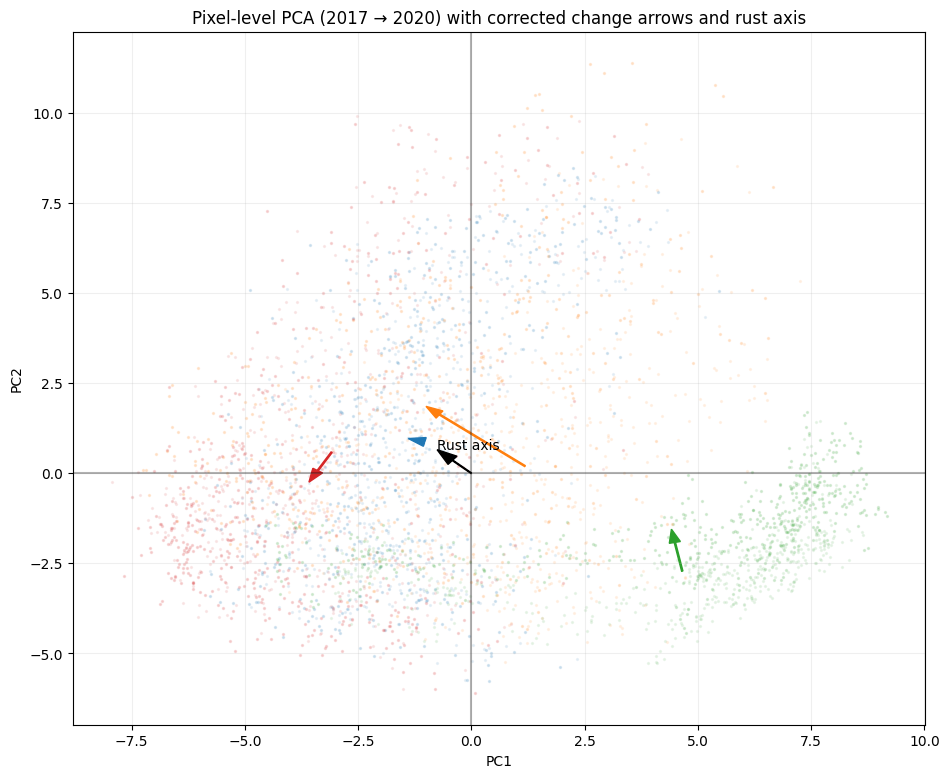

In [18]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import re

# ============================================================
# 1. INPUT PATHS
# ============================================================
paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif",
    "Control": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_1.tif"
}

rivers = list(paths.keys())

# ============================================================
# 2. LOAD MATCHED PIXELS (2017 & 2020)
# ============================================================
data_pairs = {}

def extract_year(name):
    if name is None:
        return None
    m = re.search(r"_(\d{4})_", name)
    return int(m.group(1)) if m else None

for r, path in paths.items():

    print(f"\nProcessing {r}")

    with rasterio.open(path) as src:

        years = np.array([extract_year(n) for n in src.descriptions])

        groups = defaultdict(list)
        for i, y in enumerate(years):
            if y is not None:
                groups[y].append(i)

        if 2017 not in groups or 2020 not in groups:
            print(f"{r}: missing years")
            continue

        idx17 = [i + 1 for i in sorted(groups[2017])[:64] if i + 1 <= src.count]
        idx20 = [i + 1 for i in sorted(groups[2020])[:64] if i + 1 <= src.count]

        img17 = src.read(idx17).reshape(64, -1).T
        img20 = src.read(idx20).reshape(64, -1).T

        valid = np.isfinite(img17).all(axis=1) & np.isfinite(img20).all(axis=1)

        X17 = img17[valid]
        X20 = img20[valid]

        data_pairs[r] = (X17, X20)

        print(f"{r}: pixels = {X17.shape[0]}")

# ============================================================
# 3. BALANCE PIXELS ACROSS RIVERS
# ============================================================
min_n = min(v[0].shape[0] for v in data_pairs.values())
print("\nBalanced pixels per river:", min_n)

X17_all, X20_all, labels = [], [], []

for r in rivers:

    X17, X20 = data_pairs[r]

    idx = np.random.choice(len(X17), min_n, replace=False)

    X17_all.append(X17[idx])
    X20_all.append(X20[idx])

    labels += [r] * min_n

X17_all = np.vstack(X17_all)
X20_all = np.vstack(X20_all)
labels = np.array(labels)

# ============================================================
# 4. PCA ON ALL PIXELS (JOINT SPACE)
# ============================================================
X = np.vstack([X17_all, X20_all])
X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
Z = pca.fit_transform(X)

Z17 = Z[:len(X17_all)]
Z20 = Z[len(X17_all):]

print("\nExplained variance:", pca.explained_variance_ratio_)

# ============================================================
# 5. PIXEL-LEVEL DISPLACEMENTS IN PCA SPACE
# ============================================================
D = Z20 - Z17  # (pixels, 2D vectors)

# ============================================================
# 6. RUST AXIS VIA SVD
# ============================================================
U, S, Vt = np.linalg.svd(D, full_matrices=False)
rust_axis = Vt[0]

# ---- FIX SIGN ORIENTATION (IMPORTANT) ----
mean_dir = D.mean(axis=0)
if np.dot(mean_dir, rust_axis) < 0:
    rust_axis = -rust_axis

print("\nRust axis (aligned):", rust_axis)

# ============================================================
# 7. PLOT PCA SPACE + TRAJECTORIES (CORRECT ARROWS)
# ============================================================
plt.figure(figsize=(11, 9))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange",
    "Control": "tab:red"
}

start = 0

for r in rivers:

    Z17_r = Z17[start:start+min_n]
    Z20_r = Z20[start:start+min_n]

    # clouds
    plt.scatter(Z17_r[:,0], Z17_r[:,1], s=2, alpha=0.08, color=colors[r])
    plt.scatter(Z20_r[:,0], Z20_r[:,1], s=2, alpha=0.15, color=colors[r])

    # mean arrow (2017 -> 2020)
    m17 = Z17_r.mean(axis=0)
    m20 = Z20_r.mean(axis=0)

    plt.arrow(
        m17[0], m17[1],
        m20[0] - m17[0],
        m20[1] - m17[1],
        color=colors[r],
        width=0.03,
        head_width=0.25,
        length_includes_head=True
    )

    start += min_n

# ============================================================
# 8. DRAW RUST AXIS (CORRECT ORIENTATION)
# ============================================================
origin = np.mean(Z, axis=0)

plt.arrow(
    origin[0], origin[1],
    rust_axis[0], rust_axis[1],
    color="black",
    width=0.02,
    head_width=0.3,
    length_includes_head=True
)

plt.text(origin[0] + rust_axis[0],
         origin[1] + rust_axis[1],
         "Rust axis", color="black")

# ============================================================
# FINAL FORMATTING
# ============================================================
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Pixel-level PCA (2017 → 2020) with corrected change arrows and rust axis")

plt.grid(alpha=0.2)
plt.show()


Processing River_A


[codecarbon INFO @ 20:57:24] Energy consumed for RAM : 0.025405 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:57:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:57:24] Energy consumed for All CPU : 0.107989 kWh
[codecarbon INFO @ 20:57:24] 0.133394 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:57:39] Energy consumed for RAM : 0.025447 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:57:39] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:57:39] Energy consumed for All CPU : 0.108166 kWh
[codecarbon INFO @ 20:57:39] 0.133613 kWh of electricity and 0.000000 L of water were used since the beginning.


River_A: valid pixels = 1382

Processing River_B
River_B: valid pixels = 495

Processing River_C


[codecarbon INFO @ 20:57:54] Energy consumed for RAM : 0.025488 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:57:54] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:57:54] Energy consumed for All CPU : 0.108343 kWh
[codecarbon INFO @ 20:57:54] 0.133831 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:58:09] Energy consumed for RAM : 0.025530 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:58:09] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:58:09] Energy consumed for All CPU : 0.108520 kWh
[codecarbon INFO @ 20:58:09] 0.134050 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:58:24] Energy consumed for RAM : 0.025572 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:58:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:58:24] Energy consumed for All CPU

River_C: valid pixels = 8430

Processing Control_1


[codecarbon INFO @ 20:58:54] Energy consumed for RAM : 0.025655 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:58:54] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:58:54] Energy consumed for All CPU : 0.109051 kWh
[codecarbon INFO @ 20:58:54] 0.134705 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:58:54] 0.002022 g.CO2eq/s mean an estimation of 63.753270726708976 kg.CO2eq/year


Control_1: valid pixels = 4163

Balanced pixels per river: 495

Explained variance:
[0.24979565 0.16888663]

Rust axis (aligned): [-0.76016317 -0.64973221]

COSINE ALIGNMENT WITH RUST AXIS
River_A: 0.7221
River_B: 0.8017
River_C: 0.9982
Control_1: -0.1396


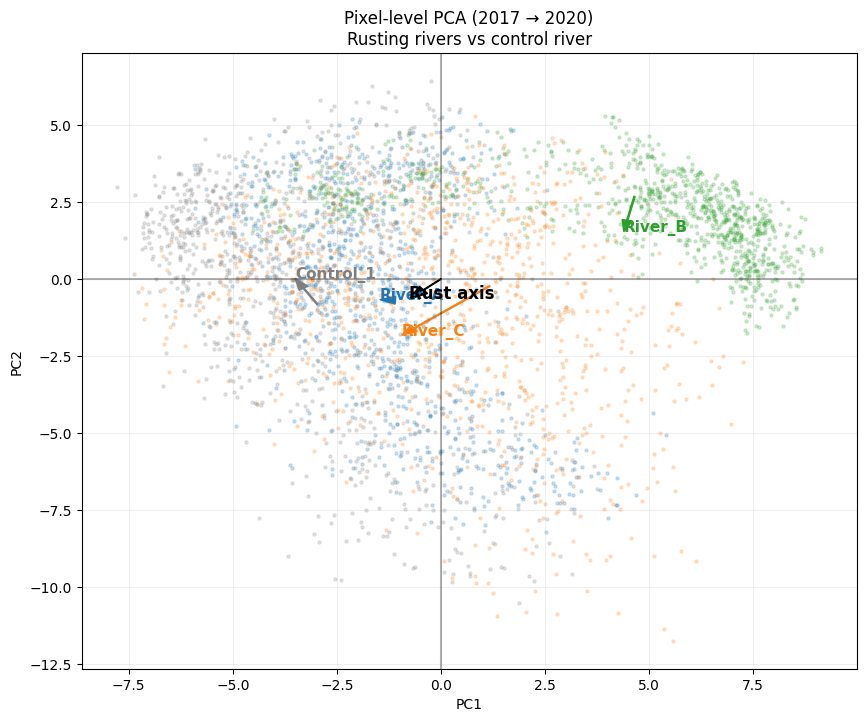

In [32]:
# Test with control
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import re

# ============================================================
# 1. INPUT PATHS
# ============================================================
paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif",
    "Control_1": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_1.tif"
    # ,"Control_2": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_2.tif",
    # "Control_3": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_3.tif"
}

rivers = list(paths.keys())

# ============================================================
# 2. LOAD MATCHED PIXELS (2017 & 2020)
# ============================================================
data_pairs = {}

def extract_year(name):
    if name is None:
        return None

    m = re.search(r"_(\d{4})_", name)

    return int(m.group(1)) if m else None

for r, path in paths.items():

    print(f"\nProcessing {r}")

    with rasterio.open(path) as src:

        years = np.array([
            extract_year(n)
            for n in src.descriptions
        ])

        groups = defaultdict(list)

        for i, y in enumerate(years):
            if y is not None:
                groups[y].append(i)

        if 2017 not in groups or 2020 not in groups:
            print(f"{r}: missing years")
            continue

        idx17 = [
            i + 1
            for i in sorted(groups[2017])[:64]
            if i + 1 <= src.count
        ]

        idx20 = [
            i + 1
            for i in sorted(groups[2020])[:64]
            if i + 1 <= src.count
        ]

        img17 = src.read(idx17).reshape(64, -1).T
        img20 = src.read(idx20).reshape(64, -1).T

        # ----------------------------------------------------
        # KEEP ONLY PIXELS VALID IN BOTH YEARS
        # ----------------------------------------------------
        valid = (
            np.isfinite(img17).all(axis=1) &
            np.isfinite(img20).all(axis=1)
        )

        X17 = img17[valid]
        X20 = img20[valid]

        data_pairs[r] = (X17, X20)

        print(f"{r}: valid pixels = {X17.shape[0]}")

# ============================================================
# 3. BALANCE PIXELS ACROSS ALL 4 RIVERS
# ============================================================
min_n = min(v[0].shape[0] for v in data_pairs.values())

print("\nBalanced pixels per river:", min_n)

X17_all = []
X20_all = []
labels = []

for r in rivers:

    X17, X20 = data_pairs[r]

    idx = np.random.choice(
        len(X17),
        min_n,
        replace=False
    )

    X17_all.append(X17[idx])
    X20_all.append(X20[idx])

    labels += [r] * min_n

X17_all = np.vstack(X17_all)
X20_all = np.vstack(X20_all)

labels = np.array(labels)

# ============================================================
# 4. PCA ON ALL PIXELS FROM ALL 4 RIVERS
# ============================================================
X = np.vstack([X17_all, X20_all])

# ------------------------------------------------------------
# GLOBAL STANDARDISATION
# ------------------------------------------------------------
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------
pca = PCA(n_components=2)

Z = pca.fit_transform(X_scaled)

print("\nExplained variance:")
print(pca.explained_variance_ratio_)

# ============================================================
# 5. SPLIT BACK INTO YEARS
# ============================================================
n_total = len(X17_all)

Z17 = Z[:n_total]
Z20 = Z[n_total:]

# ============================================================
# 6. PIXEL-LEVEL DISPLACEMENTS IN PCA SPACE
# ============================================================
D = Z20 - Z17

# ============================================================
# 7. RUST AXIS VIA SVD
# ============================================================
# LEARN ONLY FROM RUSTING RIVERS
rust_mask = labels != "Control"

D_rust = D[rust_mask]

U, S, Vt = np.linalg.svd(
    D_rust,
    full_matrices=False
)

rust_axis = Vt[0]

# ------------------------------------------------------------
# FIX SIGN ORIENTATION
# ------------------------------------------------------------
mean_dir = D_rust.mean(axis=0)

if np.dot(mean_dir, rust_axis) < 0:
    rust_axis = -rust_axis

print("\nRust axis (aligned):", rust_axis)

# ============================================================
# 8. COSINE AGREEMENT WITH RUST AXIS
# ============================================================
def cosine_to_axis(vecs, axis):

    mean_vec = vecs.mean(axis=0)

    return (
        np.dot(mean_vec, axis)
        /
        (
            np.linalg.norm(mean_vec)
            * np.linalg.norm(axis)
            + 1e-12
        )
    )

print("\n================================================")
print("COSINE ALIGNMENT WITH RUST AXIS")
print("================================================")

for r in rivers:

    mask = labels == r

    score = cosine_to_axis(
        D[mask],
        rust_axis
    )

    print(f"{r}: {score:.4f}")

# ============================================================
# 9. PLOT PCA SPACE + TRAJECTORIES
# ============================================================
plt.figure(figsize=(10, 8))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange",
    "Control_1": "tab:grey"
    # ,"Control_2": "tab:red",
    # "Control_3": "tab:red"
}

start = 0

for r in rivers:

    Z17_r = Z17[start:start+min_n]
    Z20_r = Z20[start:start+min_n]

    # --------------------------------------------------------
    # CLOUDS
    # --------------------------------------------------------
    plt.scatter(
        Z17_r[:,0],
        Z17_r[:,1],
        s=5,
        alpha=0.2,
        color=colors[r]
    )

    plt.scatter(
        Z20_r[:,0],
        Z20_r[:,1],
        s=5,
        alpha=0.2,
        color=colors[r]
    )

    # --------------------------------------------------------
    # MEAN CHANGE ARROW
    # --------------------------------------------------------
    m17 = Z17_r.mean(axis=0)
    m20 = Z20_r.mean(axis=0)

    dx = m20[0] - m17[0]
    dy = m20[1] - m17[1]

    plt.arrow(
        m17[0],
        m17[1],
        dx,
        dy,
        color=colors[r],
        width=0.03,
        head_width=0.25,
        length_includes_head=True
    )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------
    plt.text(
        m20[0],
        m20[1],
        r,
        color=colors[r],
        fontsize=11,
        weight='bold'
    )

    start += min_n

# ============================================================
# 10. DRAW RUST AXIS
# ============================================================
origin = np.mean(Z, axis=0)

plt.arrow(
    origin[0],
    origin[1],
    rust_axis[0],
    rust_axis[1],
    color="black",
    width=0.02,
    head_width=0.3,
    length_includes_head=True
)

plt.text(
    origin[0] + rust_axis[0],
    origin[1] + rust_axis[1],
    "Rust axis",
    color="black",
    fontsize=12,
    weight='bold'
)

# ============================================================
# FINAL FORMATTING
# ============================================================
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Pixel-level PCA (2017 → 2020)\n"
    "Rusting rivers vs control river"
)

plt.grid(alpha=0.2)
plt.show()


Processing River_A


[codecarbon INFO @ 20:56:09] Energy consumed for RAM : 0.025197 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:56:09] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:56:09] Energy consumed for All CPU : 0.107104 kWh
[codecarbon INFO @ 20:56:09] 0.132301 kWh of electricity and 0.000000 L of water were used since the beginning.


River_A: valid pixels = 1382

Processing River_B
River_B: valid pixels = 495

Processing River_C


[codecarbon INFO @ 20:56:24] Energy consumed for RAM : 0.025239 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:56:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:56:24] Energy consumed for All CPU : 0.107281 kWh
[codecarbon INFO @ 20:56:24] 0.132520 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:56:39] Energy consumed for RAM : 0.025280 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:56:39] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:56:39] Energy consumed for All CPU : 0.107458 kWh
[codecarbon INFO @ 20:56:39] 0.132738 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:56:54] Energy consumed for RAM : 0.025322 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:56:54] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:56:54] Energy consumed for All CPU

River_C: valid pixels = 8430

Processing Control_1


[codecarbon INFO @ 20:57:09] Energy consumed for RAM : 0.025364 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 20:57:09] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:57:09] Energy consumed for All CPU : 0.107812 kWh
[codecarbon INFO @ 20:57:09] 0.133175 kWh of electricity and 0.000000 L of water were used since the beginning.


Control_1: valid pixels = 4163

Processing Control_2
Control_2: valid pixels = 536

Processing Control_3
Control_3: valid pixels = 748

Balanced pixels per river: 495

Explained variance:
[0.25633925 0.16980861]

COSINE ALIGNMENT WITH RUST AXIS

River_A: 0.9493
River_B: 0.9182
River_C: 0.9991
Control_1: 0.1983
Control_2: 0.4282
Control_3: 0.8026


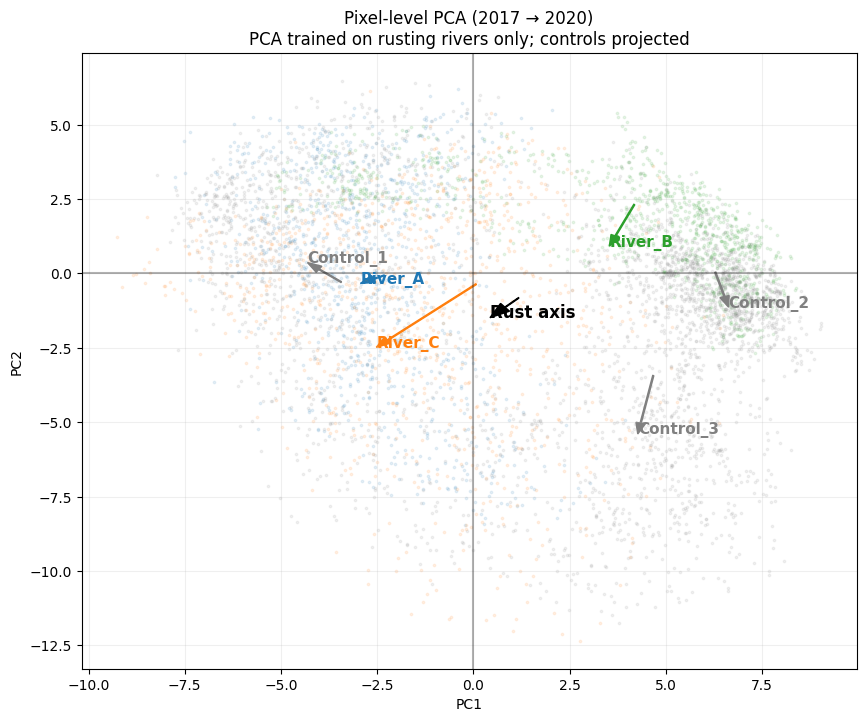

In [31]:
# ============================================================
# TEST WITH 3 CONTROL RIVERS
# PCA FIT ONLY ON RUSTING RIVERS
# CONTROLS PROJECTED AFTERWARD (GREY VISUALISATION)
# ============================================================

import numpy as np
import rasterio
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from collections import defaultdict
import re

# ============================================================
# 1. INPUT PATHS
# ============================================================

paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif",
    "Control_1": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_1.tif",
    "Control_2": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_2.tif",
    "Control_3": "/content/drive/MyDrive/AlphaEarth/alphaearth_control_4.tif"
}

rivers = list(paths.keys())

rusting_rivers = ["River_A", "River_B", "River_C"]

# ============================================================
# 2. LOAD MATCHED PIXELS (2017 & 2020)
# ============================================================

data_pairs = {}

def extract_year(name):

    if name is None:
        return None

    m = re.search(r"_(\d{4})_", name)

    return int(m.group(1)) if m else None


for r, path in paths.items():

    print(f"\nProcessing {r}")

    with rasterio.open(path) as src:

        years = np.array([
            extract_year(n)
            for n in src.descriptions
        ])

        groups = defaultdict(list)

        for i, y in enumerate(years):
            if y is not None:
                groups[y].append(i)

        if 2017 not in groups or 2020 not in groups:
            print(f"{r}: missing years")
            continue

        idx17 = [
            i + 1
            for i in sorted(groups[2017])[:64]
            if i + 1 <= src.count
        ]

        idx20 = [
            i + 1
            for i in sorted(groups[2020])[:64]
            if i + 1 <= src.count
        ]

        img17 = src.read(idx17).reshape(64, -1).T
        img20 = src.read(idx20).reshape(64, -1).T

        valid = (
            np.isfinite(img17).all(axis=1) &
            np.isfinite(img20).all(axis=1)
        )

        X17 = img17[valid]
        X20 = img20[valid]

        data_pairs[r] = (X17, X20)

        print(f"{r}: valid pixels = {X17.shape[0]}")

# ============================================================
# 3. BALANCE PIXELS ACROSS ALL RIVERS
# ============================================================

min_n = min(v[0].shape[0] for v in data_pairs.values())

print("\nBalanced pixels per river:", min_n)

X17_all = []
X20_all = []
labels = []

for r in rivers:

    X17, X20 = data_pairs[r]

    idx = np.random.choice(len(X17), min_n, replace=False)

    X17_all.append(X17[idx])
    X20_all.append(X20[idx])

    labels += [r] * min_n

X17_all = np.vstack(X17_all)
X20_all = np.vstack(X20_all)

labels = np.array(labels)

# ============================================================
# 4. PCA TRAINING DATA (RUSTING ONLY)
# ============================================================

rust_mask = np.isin(labels, rusting_rivers)

X_rust = np.vstack([
    X17_all[rust_mask],
    X20_all[rust_mask]
])

# ============================================================
# 5. STANDARDISATION (RUST ONLY)
# ============================================================

scaler = StandardScaler()
scaler.fit(X_rust)

X_all = np.vstack([X17_all, X20_all])
X_all_scaled = scaler.transform(X_all)

X_rust_scaled = scaler.transform(X_rust)

# ============================================================
# 6. PCA FIT (RUST ONLY)
# ============================================================

pca = PCA(n_components=2)
pca.fit(X_rust_scaled)

Z = pca.transform(X_all_scaled)

print("\nExplained variance:")
print(pca.explained_variance_ratio_)

# ============================================================
# 7. SPLIT INTO YEARS
# ============================================================

n_total = len(X17_all)

Z17 = Z[:n_total]
Z20 = Z[n_total:]

# ============================================================
# 8. DISPLACEMENTS
# ============================================================

D = Z20 - Z17
D_rust = D[rust_mask]

# ============================================================
# 9. RUST AXIS (SVD)
# ============================================================

U, S, Vt = np.linalg.svd(D_rust, full_matrices=False)
rust_axis = Vt[0]

if np.dot(D_rust.mean(axis=0), rust_axis) < 0:
    rust_axis = -rust_axis

# ============================================================
# 10. COSINE ALIGNMENT
# ============================================================

def cosine_to_axis(vecs, axis):
    mean_vec = vecs.mean(axis=0)
    return np.dot(mean_vec, axis) / (
        np.linalg.norm(mean_vec) * np.linalg.norm(axis) + 1e-12
    )

print("\nCOSINE ALIGNMENT WITH RUST AXIS\n")

for r in rivers:
    mask = labels == r
    score = cosine_to_axis(D[mask], rust_axis)
    print(f"{r}: {score:.4f}")

# ============================================================
# 11. PLOTTING
# ============================================================

plt.figure(figsize=(10, 8))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange",
    "Control_1": "grey",
    "Control_2": "grey",
    "Control_3": "grey"
}

start = 0

for r in rivers:

    Z17_r = Z17[start:start+min_n]
    Z20_r = Z20[start:start+min_n]

    c = colors[r]

    # -----------------------
    # 2017 CLOUD
    # -----------------------
    plt.scatter(Z17_r[:,0], Z17_r[:,1],
                s=3, alpha=0.1, color=c)

    # -----------------------
    # 2020 CLOUD
    # -----------------------
    plt.scatter(Z20_r[:,0], Z20_r[:,1],
                s=3, alpha=0.10, color=c)

    # -----------------------
    # MEAN SHIFT ARROW
    # -----------------------
    m17 = Z17_r.mean(axis=0)
    m20 = Z20_r.mean(axis=0)

    dx = m20[0] - m17[0]
    dy = m20[1] - m17[1]

    plt.arrow(
        m17[0], m17[1], dx, dy,
        color=c,
        width=0.03,
        head_width=0.25,
        length_includes_head=True
    )

    plt.text(m20[0], m20[1], r,
             color=c, fontsize=11, weight='bold')

    start += min_n

# ============================================================
# 12. RUST AXIS
# ============================================================

origin = np.mean(Z, axis=0)

plt.arrow(
    origin[0], origin[1],
    rust_axis[0], rust_axis[1],
    color="black",
    width=0.02,
    head_width=0.35,
    length_includes_head=True
)

plt.text(
    origin[0] + rust_axis[0],
    origin[1] + rust_axis[1],
    "Rust axis",
    color="black",
    fontsize=12,
    weight='bold'
)

# ============================================================
# 13. FINAL STYLE
# ============================================================

plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Pixel-level PCA (2017 → 2020)\n"
    "PCA trained on rusting rivers only; controls projected"
)

plt.grid(alpha=0.2)

plt.show()


Processing River_A
River_A: valid pixels = 1382

Processing River_B
River_B: valid pixels = 495

Processing River_C
River_C: valid pixels = 8430

Balanced pixels per river: 495

Explained variance:
[0.32402199 0.19032213]

Rust axis: [ 0.30142592 -0.9534896 ]

TEST RIVER SCORE
Mean projection onto rust axis: 1.256946272540646
Interpretation: test river changes align with training rust direction


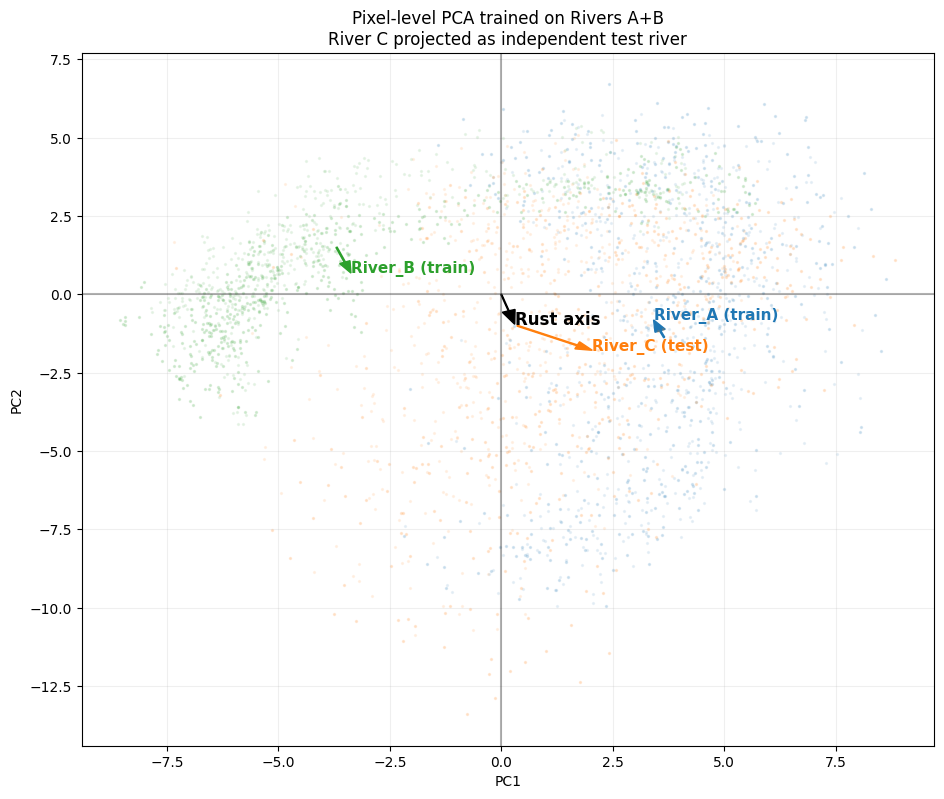

In [12]:
# Test on River C

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import re

# ============================================================
# 1. INPUT PATHS
# ============================================================
paths = {
    "River_A": "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif",
    "River_B": "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif",
    "River_C": "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok.tif"
}

train_rivers = ["River_A", "River_B"]
test_rivers = ["River_C"]

all_rivers = train_rivers + test_rivers

# ============================================================
# 2. LOAD MATCHED PIXELS (2017 & 2020)
# ============================================================
data_pairs = {}

def extract_year(name):
    if name is None:
        return None
    m = re.search(r"_(\d{4})_", name)
    return int(m.group(1)) if m else None

for r, path in paths.items():

    print(f"\nProcessing {r}")

    with rasterio.open(path) as src:

        years = np.array([extract_year(n) for n in src.descriptions])

        groups = defaultdict(list)

        for i, y in enumerate(years):
            if y is not None:
                groups[y].append(i)

        if 2017 not in groups or 2020 not in groups:
            print(f"{r}: missing years")
            continue

        idx17 = [i + 1 for i in sorted(groups[2017])[:64] if i + 1 <= src.count]
        idx20 = [i + 1 for i in sorted(groups[2020])[:64] if i + 1 <= src.count]

        img17 = src.read(idx17).reshape(64, -1).T
        img20 = src.read(idx20).reshape(64, -1).T

        valid = np.isfinite(img17).all(axis=1) & np.isfinite(img20).all(axis=1)

        X17 = img17[valid]
        X20 = img20[valid]

        data_pairs[r] = (X17, X20)

        print(f"{r}: valid pixels = {X17.shape[0]}")

# ============================================================
# 3. BALANCE PIXELS ACROSS ALL RIVERS
# ============================================================
min_n = min(v[0].shape[0] for v in data_pairs.values())

print("\nBalanced pixels per river:", min_n)

X17_all = []
X20_all = []
river_labels = []

for r in all_rivers:

    X17, X20 = data_pairs[r]

    idx = np.random.choice(len(X17), min_n, replace=False)

    X17_all.append(X17[idx])
    X20_all.append(X20[idx])

    river_labels += [r] * min_n

X17_all = np.vstack(X17_all)
X20_all = np.vstack(X20_all)

river_labels = np.array(river_labels)

# ============================================================
# 4. BUILD TRAINING SET (A+B ONLY)
# ============================================================
train_mask = np.isin(river_labels, train_rivers)

X_train = np.vstack([
    X17_all[train_mask],
    X20_all[train_mask]
])

# ============================================================
# 5. GLOBAL SCALER FIT ON TRAINING DATA ONLY
# ============================================================
scaler = StandardScaler()
scaler.fit(X_train)

# ============================================================
# 6. APPLY SAME SCALER TO ALL RIVERS
# ============================================================
X17_scaled = scaler.transform(X17_all)
X20_scaled = scaler.transform(X20_all)

# ============================================================
# 7. PCA FIT ON TRAINING RIVERS ONLY
# ============================================================
X_pca_train = np.vstack([
    X17_scaled[train_mask],
    X20_scaled[train_mask]
])

pca = PCA(n_components=2)
pca.fit(X_pca_train)

# ============================================================
# 8. PROJECT ALL RIVERS INTO SAME PCA SPACE
# ============================================================
Z17 = pca.transform(X17_scaled)
Z20 = pca.transform(X20_scaled)

print("\nExplained variance:")
print(pca.explained_variance_ratio_)

# ============================================================
# 9. PIXEL-LEVEL DELTAS
# ============================================================
D = Z20 - Z17

# ============================================================
# 10. TRAINING-ONLY RUST AXIS
# ============================================================
D_train = D[train_mask]

U, S, Vt = np.linalg.svd(D_train, full_matrices=False)

rust_axis = Vt[0]

# ------------------------------------------------------------
# FIX SIGN AMBIGUITY
# ------------------------------------------------------------
mean_dir = D_train.mean(axis=0)

if np.dot(mean_dir, rust_axis) < 0:
    rust_axis = -rust_axis

print("\nRust axis:", rust_axis)

# ============================================================
# 11. TEST RIVER SCORE
# ============================================================
D_test = D[~train_mask]

test_projection = np.dot(D_test, rust_axis)

test_score = np.mean(test_projection)

print("\n================================================")
print("TEST RIVER SCORE")
print("================================================")
print("Mean projection onto rust axis:", test_score)

if test_score > 0:
    print("Interpretation: test river changes align with training rust direction")
else:
    print("Interpretation: test river changes oppose training rust direction")

# ============================================================
# 12. PLOT
# ============================================================
plt.figure(figsize=(11, 9))

colors = {
    "River_A": "tab:blue",
    "River_B": "tab:green",
    "River_C": "tab:orange"
}

start = 0

for r in all_rivers:

    Z17_r = Z17[start:start+min_n]
    Z20_r = Z20[start:start+min_n]

    # --------------------------------------------------------
    # CLOUDS
    # --------------------------------------------------------
    plt.scatter(
        Z17_r[:,0],
        Z17_r[:,1],
        s=2,
        alpha=0.08,
        color=colors[r]
    )

    plt.scatter(
        Z20_r[:,0],
        Z20_r[:,1],
        s=2,
        alpha=0.15,
        color=colors[r]
    )

    # --------------------------------------------------------
    # MEAN ARROW
    # --------------------------------------------------------
    m17 = Z17_r.mean(axis=0)
    m20 = Z20_r.mean(axis=0)

    dx = m20[0] - m17[0]
    dy = m20[1] - m17[1]

    plt.arrow(
        m17[0],
        m17[1],
        dx,
        dy,
        color=colors[r],
        width=0.03,
        head_width=0.25,
        length_includes_head=True
    )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------
    label = r

    if r in train_rivers:
        label += " (train)"
    else:
        label += " (test)"

    plt.text(
        m20[0],
        m20[1],
        label,
        color=colors[r],
        fontsize=11,
        weight='bold'
    )

    start += min_n

# ============================================================
# 13. DRAW RUST AXIS
# ============================================================
origin = np.mean(np.vstack([Z17[train_mask], Z20[train_mask]]), axis=0)

plt.arrow(
    origin[0],
    origin[1],
    rust_axis[0],
    rust_axis[1],
    color="black",
    width=0.02,
    head_width=0.3,
    length_includes_head=True
)

plt.text(
    origin[0] + rust_axis[0],
    origin[1] + rust_axis[1],
    "Rust axis",
    color="black",
    fontsize=12,
    weight='bold'
)

# ============================================================
# FINAL FORMATTING
# ============================================================
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Pixel-level PCA trained on Rivers A+B\n"
    "River C projected as independent test river"
)

plt.grid(alpha=0.2)
plt.show()

In [10]:
import numpy as np

print("Checking bad rows...")

idx = 0

for r in rivers:

    years = np.array(river_results[r]["years"])
    means = np.array(river_results[r]["means"])

    for i in range(means.shape[0]):

        row = means[i]

        if not np.isfinite(row).all():

            print("\n❌ BAD SAMPLE FOUND")
            print("River:", r)
            print("Year:", years[i])
            print("Index in river:", i)
            print("Row:", row)

        idx += 1

Checking bad rows...

❌ BAD SAMPLE FOUND
River: River_A
Year: 2018
Index in river: 1
Row: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]


###What Follows is testing and proof of concept only

In [ ]:
# Outdated?

import rasterio
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# ------------------------------------------------------------
# 1. LOAD
# ------------------------------------------------------------
path_A = "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif"
path_B = "/content/drive/MyDrive/AlphaEarth/alphaearth_Kugururok.tif"
path_C = "/content/drive/MyDrive/AlphaEarth/alphaearth_Anaktok_64bands.tif"

src = rasterio.open(path_A)

data = src.read()  # (bands, y, x)
names = list(src.descriptions)

print("Original shape:", data.shape)

# ------------------------------------------------------------
# 2. EXTRACT YEARS FROM BAND NAMES
# ------------------------------------------------------------
def extract_year(name):
    if name is None:
        return None
    m = re.search(r"_(\d{4})_", name)
    return int(m.group(1)) if m else None

years = np.array([extract_year(n) for n in names])

# ------------------------------------------------------------
# 3. GROUP BANDS BY YEAR (CRITICAL FIX)
# ------------------------------------------------------------
year_groups = defaultdict(list)

for i, y in enumerate(years):
    if y is not None:
        year_groups[y].append(i)

print("\nBands per year:")
for y in sorted(year_groups.keys()):
    print(y, "→", len(year_groups[y]))

# ------------------------------------------------------------
# 4. BUILD CLEAN YEARLY STACK (NO POSITION ASSUMPTIONS)
# ------------------------------------------------------------
clean_years = []
clean_blocks = []

for y in sorted(year_groups.keys()):

    idx = year_groups[y]

    # skip empty or corrupted years
    if len(idx) == 0:
        continue

    # ensure consistent ordering
    idx = sorted(idx)

    # enforce 64-band structure (truncate if needed, safer than crash)
    if len(idx) < 64:
        print(f"Skipping incomplete year {y} (only {len(idx)} bands)")
        continue

    idx = idx[:64]

    # extract year block
    year_block = data[idx, :, :]

    clean_blocks.append(year_block)
    clean_years.append(y)

clean_reshaped = np.stack(clean_blocks)

print("\nFinal cleaned shape:", clean_reshaped.shape)
print("Years retained:", clean_years)

# ------------------------------------------------------------
# 5. QUICK VISUAL CHECK
# ------------------------------------------------------------
img = clean_reshaped[0]

rgb = np.stack([
    img[0],   # A01
    img[16],  # A16
    img[8]    # A09
], axis=-1)

# normalize safely
rgb_min = np.nanmin(rgb)
rgb_max = np.nanmax(rgb)
rgb = (rgb - rgb_min) / (rgb_max - rgb_min + 1e-9)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title(f"Clean embeddings (Year {clean_years[0]})")
plt.axis("off")
plt.show()

In [46]:
import rasterio

path = "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif"
src = rasterio.open(path)

print("Width:", src.width)
print("Height:", src.height)
print("Bands:", src.count)

Width: 619
Height: 322
Bands: 1152


In [47]:
print(src.descriptions[:20])  # shows first band names if available

('xv49mzihxdvh51i4s_2017_A00', 'xv49mzihxdvh51i4s_2017_A01', 'xv49mzihxdvh51i4s_2017_A02', 'xv49mzihxdvh51i4s_2017_A03', 'xv49mzihxdvh51i4s_2017_A04', 'xv49mzihxdvh51i4s_2017_A05', 'xv49mzihxdvh51i4s_2017_A06', 'xv49mzihxdvh51i4s_2017_A07', 'xv49mzihxdvh51i4s_2017_A08', 'xv49mzihxdvh51i4s_2017_A09', 'xv49mzihxdvh51i4s_2017_A10', 'xv49mzihxdvh51i4s_2017_A11', 'xv49mzihxdvh51i4s_2017_A12', 'xv49mzihxdvh51i4s_2017_A13', 'xv49mzihxdvh51i4s_2017_A14', 'xv49mzihxdvh51i4s_2017_A15', 'xv49mzihxdvh51i4s_2017_A16', 'xv49mzihxdvh51i4s_2017_A17', 'xv49mzihxdvh51i4s_2017_A18', 'xv49mzihxdvh51i4s_2017_A19')


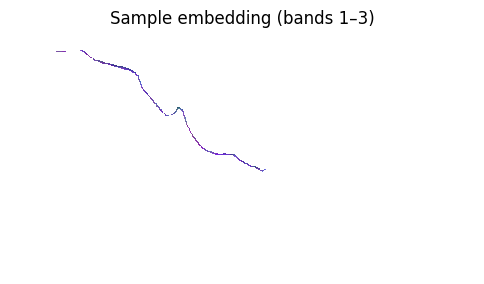

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# read first 3 bands
b1 = src.read(1)
b2 = src.read(2)
b3 = src.read(3)

img = np.stack([b1, b2, b3], axis=-1)

# normalize for visualization
img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img))

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Sample embedding (bands 1–3)")
plt.axis("off")
plt.show()

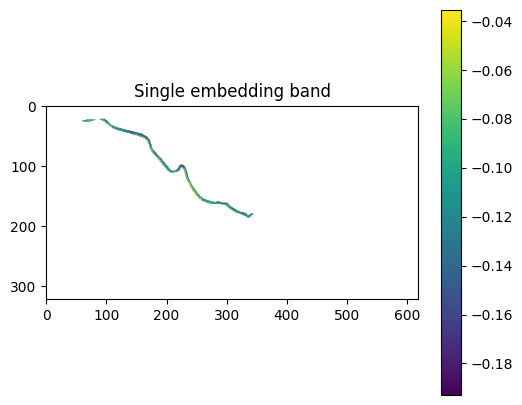

In [49]:
band = src.read(1)

plt.figure(figsize=(6,5))
plt.imshow(band, cmap="viridis")
plt.colorbar()
plt.title("Single embedding band")
plt.show()


In [54]:
import rasterio

path = "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif"
src = rasterio.open(path)

print("Total bands:", src.count)
print("First 50 band names:")
print(src.descriptions[:50])

from collections import Counter

names = list(src.descriptions)

# if names are missing, stop here
if names[0] is None:
    print("No metadata band names — cannot directly detect duplication")
else:
    # extract year prefix
    years = [n.split("_")[0] for n in names if "_" in n]

    counts = Counter(years)

    print("Year frequency:")
    for k, v in counts.items():
        print(k, "→", v)

Total bands: 1152
First 50 band names:
('xv49mzihxdvh51i4s_2017_A00', 'xv49mzihxdvh51i4s_2017_A01', 'xv49mzihxdvh51i4s_2017_A02', 'xv49mzihxdvh51i4s_2017_A03', 'xv49mzihxdvh51i4s_2017_A04', 'xv49mzihxdvh51i4s_2017_A05', 'xv49mzihxdvh51i4s_2017_A06', 'xv49mzihxdvh51i4s_2017_A07', 'xv49mzihxdvh51i4s_2017_A08', 'xv49mzihxdvh51i4s_2017_A09', 'xv49mzihxdvh51i4s_2017_A10', 'xv49mzihxdvh51i4s_2017_A11', 'xv49mzihxdvh51i4s_2017_A12', 'xv49mzihxdvh51i4s_2017_A13', 'xv49mzihxdvh51i4s_2017_A14', 'xv49mzihxdvh51i4s_2017_A15', 'xv49mzihxdvh51i4s_2017_A16', 'xv49mzihxdvh51i4s_2017_A17', 'xv49mzihxdvh51i4s_2017_A18', 'xv49mzihxdvh51i4s_2017_A19', 'xv49mzihxdvh51i4s_2017_A20', 'xv49mzihxdvh51i4s_2017_A21', 'xv49mzihxdvh51i4s_2017_A22', 'xv49mzihxdvh51i4s_2017_A23', 'xv49mzihxdvh51i4s_2017_A24', 'xv49mzihxdvh51i4s_2017_A25', 'xv49mzihxdvh51i4s_2017_A26', 'xv49mzihxdvh51i4s_2017_A27', 'xv49mzihxdvh51i4s_2017_A28', 'xv49mzihxdvh51i4s_2017_A29', 'xv49mzihxdvh51i4s_2017_A30', 'xv49mzihxdvh51i4s_2017_A31', 

In [11]:
import numpy as np
import rasterio

path = "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif"

src = rasterio.open(path)

data = src.read()  # (bands, y, x)

print("Full shape:", data.shape)

# ------------------------------------------------------------
# 1. DEFINE STRUCTURE
# ------------------------------------------------------------
year_band_size = 64
n_bands = data.shape[0]

if n_bands % year_band_size != 0:
    raise ValueError("Band count is not divisible by 64 — check export")

n_years = n_bands // year_band_size

print("Years detected:", n_years)

# ------------------------------------------------------------
# 2. RESHAPE → (year, band, y, x)
# ------------------------------------------------------------
reshaped = data.reshape(n_years, year_band_size, data.shape[1], data.shape[2])

print("Reshaped array:", reshaped.shape)

Full shape: (1152, 322, 619)
Years detected: 18
Reshaped array: (18, 64, 322, 619)


In [45]:
import rasterio

path = "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif"
src = rasterio.open(path)

print("Total bands:", src.count)
print("First 20 band descriptions:")
print(src.descriptions[:])

Total bands: 1152
First 20 band descriptions:
('xv49mzihxdvh51i4s_2017_A00', 'xv49mzihxdvh51i4s_2017_A01', 'xv49mzihxdvh51i4s_2017_A02', 'xv49mzihxdvh51i4s_2017_A03', 'xv49mzihxdvh51i4s_2017_A04', 'xv49mzihxdvh51i4s_2017_A05', 'xv49mzihxdvh51i4s_2017_A06', 'xv49mzihxdvh51i4s_2017_A07', 'xv49mzihxdvh51i4s_2017_A08', 'xv49mzihxdvh51i4s_2017_A09', 'xv49mzihxdvh51i4s_2017_A10', 'xv49mzihxdvh51i4s_2017_A11', 'xv49mzihxdvh51i4s_2017_A12', 'xv49mzihxdvh51i4s_2017_A13', 'xv49mzihxdvh51i4s_2017_A14', 'xv49mzihxdvh51i4s_2017_A15', 'xv49mzihxdvh51i4s_2017_A16', 'xv49mzihxdvh51i4s_2017_A17', 'xv49mzihxdvh51i4s_2017_A18', 'xv49mzihxdvh51i4s_2017_A19', 'xv49mzihxdvh51i4s_2017_A20', 'xv49mzihxdvh51i4s_2017_A21', 'xv49mzihxdvh51i4s_2017_A22', 'xv49mzihxdvh51i4s_2017_A23', 'xv49mzihxdvh51i4s_2017_A24', 'xv49mzihxdvh51i4s_2017_A25', 'xv49mzihxdvh51i4s_2017_A26', 'xv49mzihxdvh51i4s_2017_A27', 'xv49mzihxdvh51i4s_2017_A28', 'xv49mzihxdvh51i4s_2017_A29', 'xv49mzihxdvh51i4s_2017_A30', 'xv49mzihxdvh51i4s_2017

Original shape: (1152, 322, 619)
Years kept: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Bands before: 1152
Bands after: 576
Final shape: (9, 64, 322, 619)


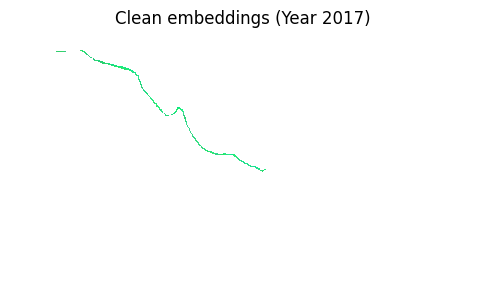

In [11]:
import rasterio
import numpy as np
import re
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD
# ------------------------------------------------------------
path = "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif"
src = rasterio.open(path)

data = src.read()  # (bands, y, x)
names = list(src.descriptions)

print("Original shape:", data.shape)

# ------------------------------------------------------------
# 2. EXTRACT YEARS FROM BAND NAMES
# ------------------------------------------------------------
def extract_year(name):
    if name is None:
        return None
    m = re.search(r"_(\d{4})_", name)
    return int(m.group(1)) if m else None

years = np.array([extract_year(n) for n in names])

# ------------------------------------------------------------
# 3. FIND DUPLICATES
# ------------------------------------------------------------
unique_years = []
seen = set()
keep_indices = []

for i, y in enumerate(years):
    if y is None:
        continue

    # take ONLY first occurrence of each year block
    if y not in seen:
        seen.add(y)
        unique_years.append(y)

        # assume 64-band block
        keep_indices.extend(range(i, i + 64))

# remove duplicates / out-of-bounds
keep_indices = sorted(set([i for i in keep_indices if i < data.shape[0]]))

print("Years kept:", sorted(unique_years))
print("Bands before:", data.shape[0])
print("Bands after:", len(keep_indices))

# ------------------------------------------------------------
# 4. FILTER DATA
# ------------------------------------------------------------
clean_data = data[keep_indices, :, :]

# ------------------------------------------------------------
# 5. RESHAPE → (year, 64, y, x)
# ------------------------------------------------------------
n_years = len(unique_years)
clean_reshaped = clean_data.reshape(n_years, 64, data.shape[1], data.shape[2])

print("Final shape:", clean_reshaped.shape)

# ------------------------------------------------------------
# 6. QUICK VISUAL CHECK
# ------------------------------------------------------------
img = clean_reshaped[0]

rgb = np.stack([
    img[0],   # A01
    img[16],  # A16
    img[8]    # A09
], axis=-1)

# normalize
rgb = (rgb - np.nanmin(rgb)) / (np.nanmax(rgb) - np.nanmin(rgb))

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title(f"Clean embeddings (Year {unique_years[0]})")
plt.axis("off")
plt.show()

Original shape: (1152, 322, 619)

Bands per year:
2017 → 128
2018 → 128
2019 → 128
2020 → 128
2021 → 128
2022 → 128
2023 → 128
2024 → 128
2025 → 128

Final cleaned shape: (9, 64, 322, 619)
Years retained: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


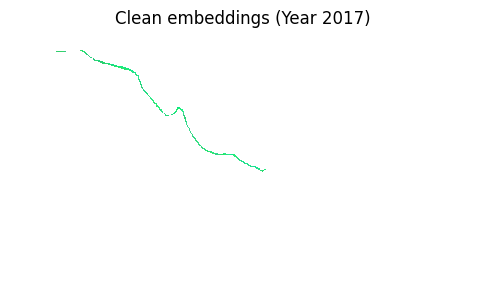

In [5]:
#### START HERE

import rasterio
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# ------------------------------------------------------------
# 1. LOAD
# ------------------------------------------------------------
path = "/content/drive/MyDrive/AlphaEarth/alphaearth_Agashashok.tif"
src = rasterio.open(path)

data = src.read()  # (bands, y, x)
names = list(src.descriptions)

print("Original shape:", data.shape)

# ------------------------------------------------------------
# 2. EXTRACT YEARS FROM BAND NAMES
# ------------------------------------------------------------
def extract_year(name):
    if name is None:
        return None
    m = re.search(r"_(\d{4})_", name)
    return int(m.group(1)) if m else None

years = np.array([extract_year(n) for n in names])

# ------------------------------------------------------------
# 3. GROUP BANDS BY YEAR (CRITICAL FIX)
# ------------------------------------------------------------
year_groups = defaultdict(list)

for i, y in enumerate(years):
    if y is not None:
        year_groups[y].append(i)

print("\nBands per year:")
for y in sorted(year_groups.keys()):
    print(y, "→", len(year_groups[y]))

# ------------------------------------------------------------
# 4. BUILD CLEAN YEARLY STACK (NO POSITION ASSUMPTIONS)
# ------------------------------------------------------------
clean_years = []
clean_blocks = []

for y in sorted(year_groups.keys()):

    idx = year_groups[y]

    # skip empty or corrupted years
    if len(idx) == 0:
        continue

    # ensure consistent ordering
    idx = sorted(idx)

    # enforce 64-band structure (truncate if needed, safer than crash)
    if len(idx) < 64:
        print(f"Skipping incomplete year {y} (only {len(idx)} bands)")
        continue

    idx = idx[:64]

    # extract year block
    year_block = data[idx, :, :]

    clean_blocks.append(year_block)
    clean_years.append(y)

clean_reshaped = np.stack(clean_blocks)

print("\nFinal cleaned shape:", clean_reshaped.shape)
print("Years retained:", clean_years)

# ------------------------------------------------------------
# 5. QUICK VISUAL CHECK
# ------------------------------------------------------------
img = clean_reshaped[0]

rgb = np.stack([
    img[0],   # A01
    img[16],  # A16
    img[8]    # A09
], axis=-1)

# normalize safely
rgb_min = np.nanmin(rgb)
rgb_max = np.nanmax(rgb)
rgb = (rgb - rgb_min) / (rgb_max - rgb_min + 1e-9)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title(f"Clean embeddings (Year {clean_years[0]})")
plt.axis("off")
plt.show()

In [15]:
import numpy as np

print("VALID YEARS:", clean_years)

empty_years = []

for i, y in enumerate(clean_years):

    # (64, y, x)
    year_data = clean_reshaped[i]

    # flatten spatial dims
    flat = year_data.reshape(64, -1)

    # count valid pixels across all embeddings
    valid_pixels = np.sum(np.isfinite(flat))

    print(f"Year {y}: valid pixels = {valid_pixels}")

    if valid_pixels == 0:
        empty_years.append(y)

print("\nEMPTY YEARS:", empty_years)

VALID YEARS: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Year 2017: valid pixels = 88448
Year 2018: valid pixels = 0
Year 2019: valid pixels = 88448
Year 2020: valid pixels = 88448
Year 2021: valid pixels = 88448
Year 2022: valid pixels = 88448
Year 2023: valid pixels = 88448
Year 2024: valid pixels = 88448
Year 2025: valid pixels = 88448

EMPTY YEARS: [np.int64(2018)]


In [17]:
import numpy as np
import re

def extract_year(name):
    if name is None:
        return None
    m = re.search(r"_(\d{4})_", name)
    return int(m.group(1)) if m else None

years = np.array([extract_year(n) for n in names])

# ------------------------------------------------------------
# helper to inspect a year
# ------------------------------------------------------------
def inspect_year(target_year):

    idx = np.where(years == target_year)[0]

    print(f"\n===== YEAR {target_year} =====")
    print("Number of bands found:", len(idx))

    if len(idx) == 0:
        print("❌ YEAR NOT PRESENT IN RAW BANDS")
        return

    # extract data
    block = data[idx, :, :]

    print("Block shape:", block.shape)

    # flatten spatial dims
    flat = block.reshape(block.shape[0], -1)

    # stats
    print("NaN fraction per band:")
    nan_frac = np.mean(~np.isfinite(flat), axis=1)
    print("  min:", np.min(nan_frac))
    print("  max:", np.max(nan_frac))

    print("Total finite pixels:", np.sum(np.isfinite(flat)))

    # check if completely empty
    if np.all(~np.isfinite(flat)):
        print("❌ ALL VALUES ARE NaN (truly empty year)")
    else:
        print("✔ year contains valid data")

# ------------------------------------------------------------
# run checks
# ------------------------------------------------------------
inspect_year(2018)
inspect_year(2020)


===== YEAR 2018 =====
Number of bands found: 128
Block shape: (128, 322, 619)
NaN fraction per band:
  min: 0.9930663562748974
  max: 1.0
Total finite pixels: 88448
✔ year contains valid data

===== YEAR 2020 =====
Number of bands found: 128
Block shape: (128, 322, 619)
NaN fraction per band:
  min: 0.9930663562748974
  max: 1.0
Total finite pixels: 88448
✔ year contains valid data


Years used: [2017 2019 2020 2021 2022 2023 2024 2025]
Shape: (8, 64, 322, 619)
Yearly means shape: (8, 64)
Explained variance: [0.28031663 0.22473636]


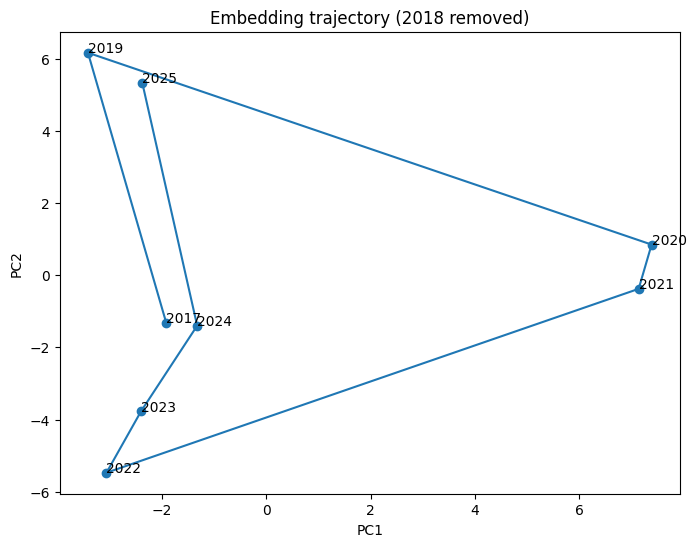


Top changing embedding dimensions:
A35: -0.050868
A53: -0.040160
A60: 0.033331
A45: -0.032717
A15: 0.027761
A51: 0.027396
A12: -0.027307
A17: -0.026904
A22: 0.026801
A09: 0.024827


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# ASSUMPTION:
# clean_years, clean_reshaped already exist
# clean_reshaped shape = (years, 64, H, W)
# ------------------------------------------------------------

# ------------------------------------------------------------
# 1. DROP 2018 (treat as missing observation)
# ------------------------------------------------------------
clean_years = np.array(clean_years)
clean_reshaped = np.array(clean_reshaped)

keep_mask = clean_years != 2018

years = clean_years[keep_mask]
data = clean_reshaped[keep_mask]

print("Years used:", years)
print("Shape:", data.shape)

# ------------------------------------------------------------
# 2. YEARLY MEAN EMBEDDINGS (NaN-safe, river pixels only)
# ------------------------------------------------------------
yearly_means = []

for i in range(data.shape[0]):
    year_data = data[i]              # (64, H, W)
    flat = year_data.reshape(64, -1) # (64, Npixels)

    mean_vec = np.nanmean(flat, axis=1)  # (64,)
    yearly_means.append(mean_vec)

yearly_means = np.array(yearly_means)

print("Yearly means shape:", yearly_means.shape)

# ------------------------------------------------------------
# 3. STANDARDISE + PCA
# ------------------------------------------------------------
X = StandardScaler().fit_transform(yearly_means)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance:", pca.explained_variance_ratio_)

# ------------------------------------------------------------
# 4. PCA TRAJECTORY PLOT
# ------------------------------------------------------------
plt.figure(figsize=(8,6))
plt.plot(X_pca[:,0], X_pca[:,1], '-o')

for i, y in enumerate(years):
    plt.text(X_pca[i,0], X_pca[i,1], str(y))

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Embedding trajectory (2018 removed)")
plt.show()

# ------------------------------------------------------------
# 5. PRE / POST SHIFT (2017 vs 2019+)
# ------------------------------------------------------------
pre_mask = years == 2017
post_mask = years >= 2019

pre_mean = np.nanmean(yearly_means[pre_mask], axis=0)
post_mean = np.nanmean(yearly_means[post_mask], axis=0)

delta = post_mean - pre_mean
importance = np.abs(delta)

top_dims = np.argsort(importance)[::-1][:10]

print("\nTop changing embedding dimensions:")
for d in top_dims:
    print(f"A{d+1:02d}: {delta[d]:.6f}")

Years used: [2017 2019 2020 2021 2022 2023 2024 2025]
Yearly means shape: (8, 64)


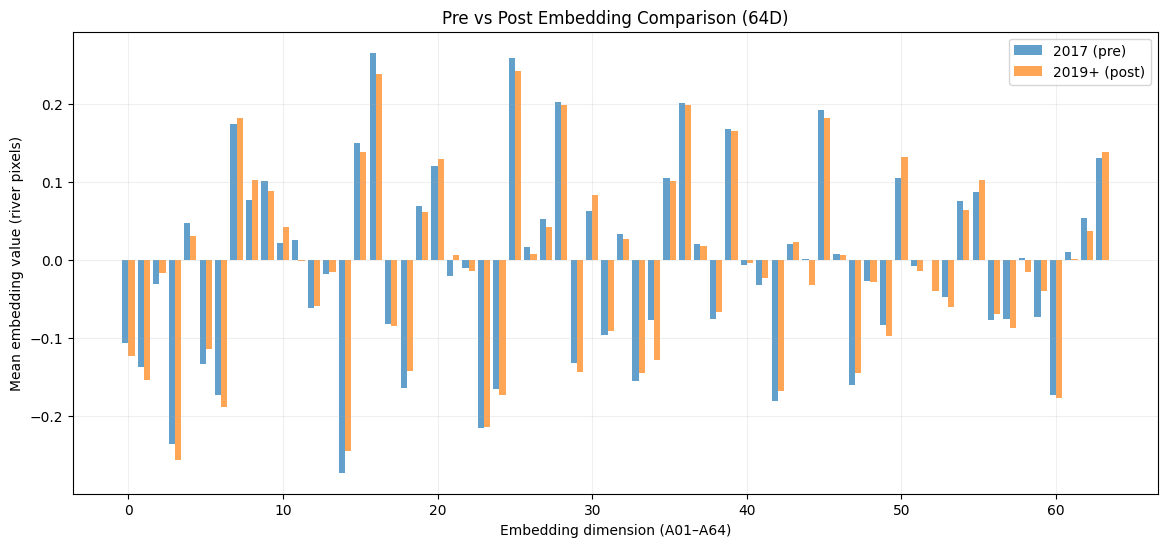

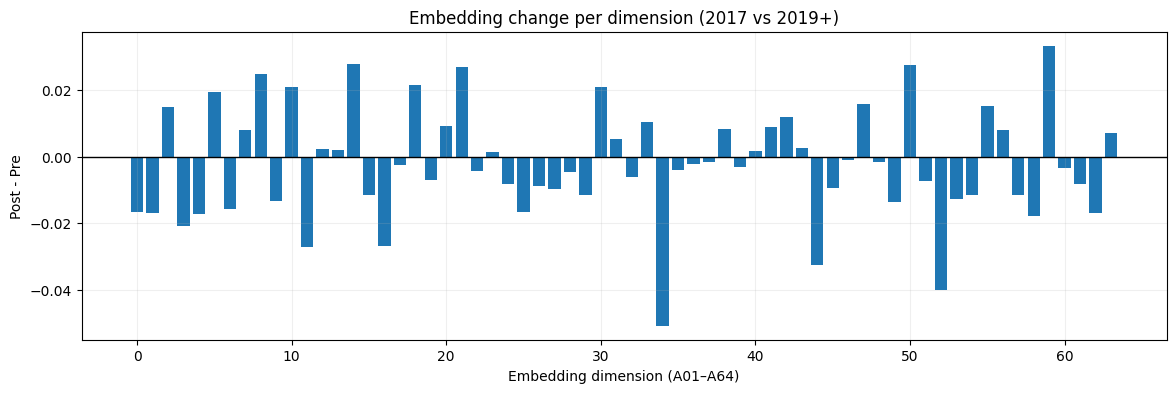


Top changing dimensions:
A35: Δ = -0.050868
A53: Δ = -0.040160
A60: Δ = 0.033331
A45: Δ = -0.032717
A15: Δ = 0.027761
A51: Δ = 0.027396
A12: Δ = -0.027307
A17: Δ = -0.026904
A22: Δ = 0.026801
A09: Δ = 0.024827


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# ASSUMPTION:
# clean_years, clean_reshaped already exist
# clean_reshaped shape = (years, 64, H, W)
# ------------------------------------------------------------

clean_years = np.array(clean_years)
clean_reshaped = np.array(clean_reshaped)

# ------------------------------------------------------------
# 1. REMOVE 2018 (missing year)
# ------------------------------------------------------------
mask = clean_years != 2018
years = clean_years[mask]
data = clean_reshaped[mask]

print("Years used:", years)

# ------------------------------------------------------------
# 2. COMPUTE YEARLY MEAN EMBEDDINGS (64-D PER YEAR)
# ------------------------------------------------------------
yearly_means = []

for i in range(data.shape[0]):
    flat = data[i].reshape(64, -1)   # (64, Npixels)
    mean_vec = np.nanmean(flat, axis=1)  # (64,)
    yearly_means.append(mean_vec)

yearly_means = np.array(yearly_means)  # (n_years, 64)

print("Yearly means shape:", yearly_means.shape)

# ------------------------------------------------------------
# 3. DEFINE PRE / POST AVERAGES
# ------------------------------------------------------------
pre_mask = years == 2017
post_mask = years >= 2019

pre_vec = np.nanmean(yearly_means[pre_mask], axis=0)   # (64,)
post_vec = np.nanmean(yearly_means[post_mask], axis=0) # (64,)

delta = post_vec - pre_vec

# ------------------------------------------------------------
# 4. VISUALISE 64-DIMENSION COMPARISON
# ------------------------------------------------------------
dims = np.arange(64)

plt.figure(figsize=(14,6))

plt.bar(dims - 0.2, pre_vec, width=0.4, label="2017 (pre)", alpha=0.7)
plt.bar(dims + 0.2, post_vec, width=0.4, label="2019+ (post)", alpha=0.7)

plt.xlabel("Embedding dimension (A01–A64)")
plt.ylabel("Mean embedding value (river pixels)")
plt.title("Pre vs Post Embedding Comparison (64D)")

plt.legend()
plt.grid(alpha=0.2)
plt.show()

# ------------------------------------------------------------
# 5. DELTA VIEW (CHANGE MAGNITUDE PER DIMENSION)
# ------------------------------------------------------------
plt.figure(figsize=(14,4))
plt.bar(dims, delta)

plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Embedding dimension (A01–A64)")
plt.ylabel("Post - Pre")
plt.title("Embedding change per dimension (2017 vs 2019+)")
plt.grid(alpha=0.2)
plt.show()

# ------------------------------------------------------------
# 6. TOP CHANGING DIMENSIONS
# ------------------------------------------------------------
top = np.argsort(np.abs(delta))[::-1][:10]

print("\nTop changing dimensions:")
for d in top:
    print(f"A{d+1:02d}: Δ = {delta[d]:.6f}")

Normal years: [2017]
Red years: [2020]
Unspecified years: [2018 2019 2021 2022 2023 2024 2025]
Yearly means shape: (8, 64)


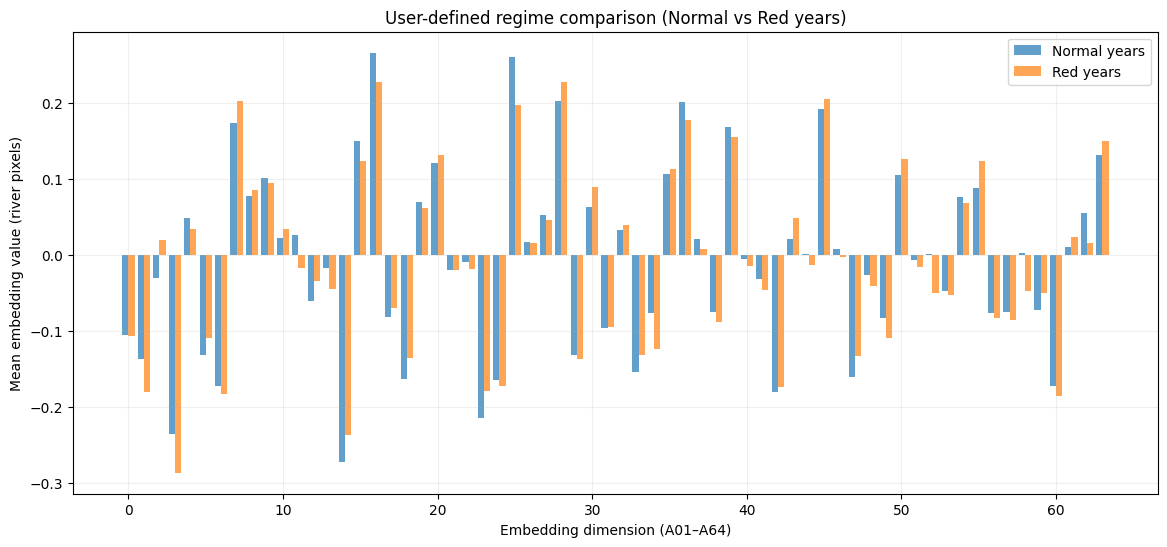

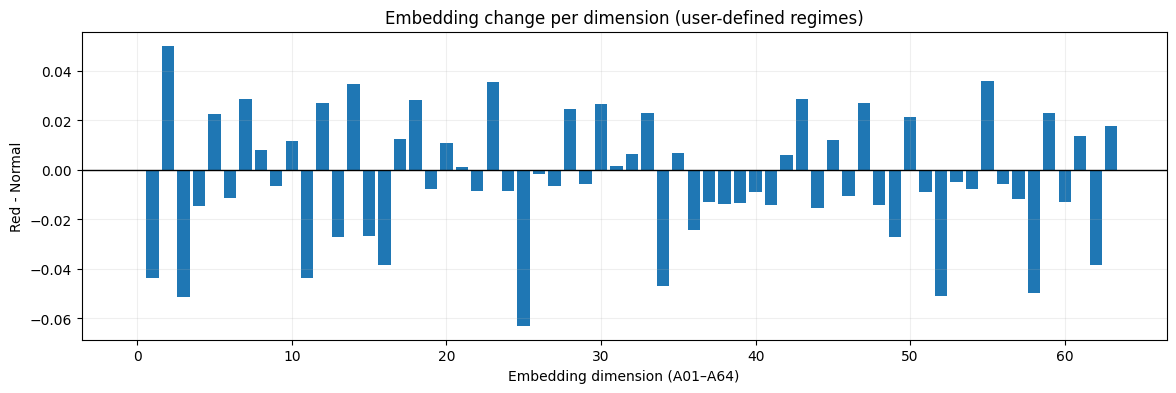


===== CHANGE SUMMARY =====
Normal years: [2017]
Red years: [2020]
Norm mean magnitude: 0.9694863184285869
Red mean magnitude: 0.9655194853118737
Shift magnitude: 0.20168142386175866

Top changing dimensions:
A26: Δ = -0.062941
A04: Δ = -0.051306
A53: Δ = -0.050932
A03: Δ = 0.050165
A59: Δ = -0.049886
A35: Δ = -0.046888
A02: Δ = -0.043672
A12: Δ = -0.043512
A63: Δ = -0.038495
A17: Δ = -0.038274
